# Model Performance Validation

Bundle: `BUNDLE-20260521-POSTCLOSE`

팀원 공유용 단일 노트북입니다. 원래 zip에 따로 들어가던 모델 파일(`latest_model.pkl`)과 성능 검증 JSON들을 이 ipynb 안에 모두 내장했습니다.

사용법:

1. 이 ipynb 파일을 Jupyter에서 엽니다.
2. `Run All`을 누릅니다.
3. 성능표/그래프를 확인합니다.
4. 모델 파일이 필요하면 실행 폴더의 `embedded_model/latest_model.pkl`을 사용합니다.

주의: 이 노트북은 모델/백테스트/드라이런 성능 검증용입니다. 실계좌 자동매매 수익 검증이나 Hot/Cold path architecture 전체 증명 패키지는 아닙니다.


## 1. Setup

공통 import와 repo root 탐색을 준비합니다. 이 셀은 노트북을 어느 폴더에서 실행해도 `artifacts/` 리포트를 안정적으로 찾기 위한 초기화 단계입니다.


In [1]:
from pathlib import Path
from datetime import datetime
from collections import Counter
import base64
import hashlib
import json
import os

import pandas as pd
import matplotlib
# Jupyter 안에서 그래프가 바로 렌더링되도록 inline backend를 명시합니다.
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


def find_repo_root(start=None):
    """Find Elephant_Lab root, unless this notebook is forced to use embedded data only."""
    if os.environ.get('ELEPHANT_NOTEBOOK_FORCE_EMBEDDED') == '1':
        return None
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'Codex-progress.md').exists() and (candidate / 'artifacts').is_dir():
            return candidate
    fallback = Path('/Users/jangjaewon/Desktop/Elephant_Lab')
    if (fallback / 'Codex-progress.md').exists() and (fallback / 'artifacts').is_dir():
        return fallback
    return None


def artifact_path(relative_path):
    """Return the local artifact path when repo artifacts are available."""
    if ROOT is None:
        return Path('__embedded_only__') / relative_path
    return ROOT / relative_path


def display_path(path):
    """Show a readable path whether the notebook is run inside or outside the repo."""
    path = Path(path)
    if ROOT is not None:
        try:
            return str(path.relative_to(ROOT))
        except ValueError:
            pass
    return str(path)


ROOT = find_repo_root()
BUNDLE_ID = 'BUNDLE-20260521-POSTCLOSE'
# 각 항목은 이 노트북이 검증에 사용하는 evidence입니다. 로컬 파일이 없으면 embedded payload를 사용합니다.
REPORTS = {
    'model_metadata': artifact_path('artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json'),
    'candidate_manifest': artifact_path('artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/candidate_manifest.json'),
    'service_policy_replay': artifact_path('artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json'),
    'c12_backtest': artifact_path('artifacts/reports/backtest/backtest_BUNDLE-20260521-POSTCLOSE_20260521_215920.json'),
    'deploy_dry_run': artifact_path('artifacts/reports/deploy/deploy_BUNDLE-20260521-POSTCLOSE_20260521_215921.json'),
    'feature_backfill': artifact_path('artifacts/reports/phase2_feature_backfill/phase2_feature_backfill_20260521_212015.json'),
    'rolling_window': artifact_path('artifacts/reports/rolling_window_ic/rolling_window_ic_experiment_20260521_213309.json'),
    'hyperparam_sweep': artifact_path('artifacts/reports/lgbm_hyperparam_sweep/lgbm_hyperparam_sweep_20260521_213320.json'),
}

# 모든 그래프에 동일한 스타일을 적용해 화면 캡처 시 일관되게 보이도록 합니다.
plt.rcParams.update({
    'figure.dpi': 135,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})

print(f'Repo root: {ROOT if ROOT else "embedded-only mode"}')
print(f'Bundle: {BUNDLE_ID}')


Repo root: /Users/jangjaewon/Desktop/Elephant_Lab
Bundle: BUNDLE-20260521-POSTCLOSE


## 2. Embedded Model and Evidence Payload

이 셀은 단일 파일 전달을 위해 모델 pkl과 검증 JSON을 노트북 안에 내장합니다. 일반적으로 읽을 필요는 없고, 아래 load/extract 셀들이 자동으로 사용합니다.


In [2]:
# Auto-generated payload for single-file sharing. 일반 검토자는 이 셀을 읽을 필요가 없습니다.
EMBEDDED_JSON = json.loads('{"model_metadata": {"version": "hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds", "bundle_id": "BUNDLE-20260521-POSTCLOSE", "train_start": "2025-05-09", "train_end": "2026-05-21", "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "feature_manifest": {"feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "panel_columns_checked": true, "include_dual_source_features": true, "include_exogenous_features": true, "requires_dual_source": true, "requires_exogenous": true}, "label_horizon_bars": 5, "target_horizon_bars": 195, "target_horizon_kind": "minute", "label_generation_version": "session_local_v2", "label_session_scope": "ticker_trading_day", "target_col": "label_195m_net_ret", "metrics": {"ic": 0.019113335610853793, "icir": 0.10261490563374868, "rank_ic": 0.015820564934159585, "arr": -0.30824987582319463, "ir": -3.5274970309982745, "mdd": -0.04673435011582612, "sr": -3.5274970309982745}, "data_version": "n30_20250509_20260521", "data_source": "artifact_bars", "synthetic_fallback": false, "requested_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "loaded_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "missing_tickers": [], "synthetic_tickers": [], "n_folds": 8, "n_train_rows": 1405090, "n_final_train_rows": 1405090, "n_cv_last_train_rows": 330078, "n_val_rows": 108335, "final_model_scope": "full_requested_window", "final_model_train_start": "2025-05-09", "final_model_train_end": "2026-05-21", "final_num_boost_round": 4, "cv_best_iterations": [6, 2, 28, 3, 2, 5, 3, 5], "fold_metrics": [{"fold": 0, "ic": 0.011429153856819432, "icir": 0.05592929055065771, "rank_ic": 0.03195595477322214, "arr": -0.4154849669921613, "ir": -8.147685273828433, "mdd": -0.04438277400805601, "sr": -8.147685273828433}, {"fold": 1, "ic": 0.059262437649366964, "icir": 0.34196112463998857, "rank_ic": 0.0249724474356596, "arr": -0.28992757900988453, "ir": -6.7672971213426845, "mdd": -0.030392068804969752, "sr": -6.7672971213426845}, {"fold": 2, "ic": 0.04909323361307155, "icir": 0.20472153652334493, "rank_ic": 0.049657976970651066, "arr": -0.1719602964606286, "ir": -1.2834312878623235, "mdd": -0.030522675066909796, "sr": -1.2834312878623235}, {"fold": 3, "ic": 0.013601280440671508, "icir": 0.0663409098644753, "rank_ic": -0.009245730038325491, "arr": -0.4402331783355613, "ir": -4.181566293346465, "mdd": -0.06249649300144835, "sr": -4.181566293346465}, {"fold": 4, "ic": 0.04788679651585508, "icir": 0.26636153497188425, "rank_ic": 0.040912177710547455, "arr": -0.15303796297893635, "ir": -1.920513941876832, "mdd": -0.030607737746719158, "sr": -1.920513941876832}, {"fold": 5, "ic": -0.06744093668287147, "icir": -0.3089262817536286, "rank_ic": -0.06628356685330014, "arr": -0.02866748232238403, "ir": -0.18032240271082783, "mdd": -0.02661957253276092, "sr": -0.18032240271082783}, {"fold": 6, "ic": 0.017928138164626635, "icir": 0.09416757254398471, "rank_ic": 0.03364207566649973, "arr": -0.5869223274552782, "ir": -2.907534275961417, "mdd": -0.09980024204779789, "sr": -2.907534275961417}, {"fold": 7, "ic": 0.021146581329290624, "icir": 0.10036355772928254, "rank_ic": 0.0209531838083223, "arr": -0.37976521303072275, "ir": -2.831625651057211, "mdd": -0.04905323771794708, "sr": -2.831625651057211}], "n_tickers": 30, "lgbm_params": {"objective": "lambdarank", "metric": "ndcg", "ndcg_eval_at": [5], "label_gain": [0, 1, 3, 7], "num_leaves": 31, "learning_rate": 0.02, "min_child_samples": 80, "subsample": 0.8, "colsample_bytree": 0.7, "random_state": 42, "feature_fraction_seed": 42, "verbose": -1, "lambda_l1": 0.2, "lambda_l2": 3.0}, "training_control": {"n_estimators": 900, "early_stopping_rounds": 80, "n_relevance_grades": 4}, "metric_scope": {"scope": "trainer_validation_proxy", "deploy_quality": false, "reason": "Trainer fold metrics are diagnostic only; C12 real backtest is required before deploy."}, "trade_no_trade_classifier": {"enabled": true, "status": "PASS", "target_col": "label_195m_net_ret", "tradeable_col": "label_195m_tradeable", "model_path": "artifacts/lgbm_research/BUNDLE-20260521-POSTCLOSE/hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds_trade_classifier.pkl", "calibration_status": "PASS", "calibration_required_for_service_gate": true, "deploy_gate_eligible": true, "calibration_reason": "walk_forward_oof_classifier", "calibration": {"calibration_status": "PASS", "calibration_reason": "walk_forward_oof_classifier", "scope": "walk_forward_oof", "n_oof_rows": 868086, "n_oof_folds": 8, "skipped_folds": 0, "positive_rate": 0.3498939045209806, "class_counts": {"0": 564348, "1": 303738}, "brier": 0.22764329879215653, "auc": 0.5095686587430678, "folds": [{"fold": 0, "n_val_rows": 108961, "positive_rate": 0.29129688604179477, "brier": 0.21092240503874554}, {"fold": 1, "n_val_rows": 109118, "positive_rate": 0.310013013434997, "brier": 0.2145629040563149}, {"fold": 2, "n_val_rows": 109161, "positive_rate": 0.3471752732202893, "brier": 0.2277630588526034}, {"fold": 3, "n_val_rows": 107659, "positive_rate": 0.324218133179762, "brier": 0.2187202205561461}, {"fold": 4, "n_val_rows": 107416, "positive_rate": 0.29776755790571235, "brier": 0.21147477820945745}, {"fold": 5, "n_val_rows": 109212, "positive_rate": 0.4261894297329964, "brier": 0.2541222374333076}, {"fold": 6, "n_val_rows": 108224, "positive_rate": 0.40716476936723833, "brier": 0.24323782378399436}, {"fold": 7, "n_val_rows": 108335, "positive_rate": 0.39481238750173075, "brier": 0.24014199686960472}]}, "n_train_rows": 1403320, "positive_rate": 0.35389861186329563, "class_counts": {"0": 906687, "1": 496633}, "params": {"objective": "binary", "metric": "binary_logloss", "learning_rate": 0.02, "num_leaves": 31, "min_child_samples": 80, "subsample": 0.8, "colsample_bytree": 0.7, "random_state": 42, "verbose": -1}}, "created_at": "2026-05-21T09:55:51.607711+00:00", "commit_hash": "32d4cb985f5dad0138cd884284e3ad55ede85eb4", "status": "candidate", "model_path": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model.pkl", "metadata_path": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json", "staged_from_existing_version": "hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds", "staged_at": "2026-05-21T18:59:25.043770+09:00"}, "candidate_manifest": {"bundle_id": "BUNDLE-20260521-POSTCLOSE", "component": "lgbm", "version": "hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds", "model_path": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model.pkl", "metadata_path": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json", "committee_path": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/committee.pkl", "factor_zoo_path": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/alpha_factor/factor_zoo.jsonl", "staged_at": "2026-05-21T18:59:25.045761+09:00", "source_model_path": "artifacts/lgbm_research/BUNDLE-20260521-POSTCLOSE/hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds.pkl", "registry_mutated": false}, "service_policy_replay": {"status": "PASS", "gate": {"status": "PASS", "blockers": [], "requires_no_naked_short": true, "requires_order_caps": true, "requires_daily_turnover_lte": 0.3, "requires_positive_material_return_bps": 15.0, "requires_service_policy_sharpe_gt": 0.0}, "metrics": {"initial_capital": 100000000.0, "final_equity": 100384465.84, "total_return": 0.003844658400000034, "total_return_bps": 38.44658400000034, "arr": 0.04953773099052783, "sr": 8.53938036959225, "mdd": -0.0003651843652231479, "days": 20}, "policy": {"initial_capital": 100000000.0, "top_k_fraction": 0.1, "max_orders_per_cycle": 3, "max_order_qty_per_order": 2, "max_names": 10, "max_single_name": 0.2, "min_cash": 0.1, "daily_turnover_cap": 0.3, "commission_bps": 5.0, "slippage_bps": 10.0, "annualization_factor": 252, "min_daily_return_std": 1e-08, "decision_stride_bars": 15, "min_holding_bars": 195, "rebalance_cooldown_bars": 195, "no_trade_score_spread": 0.02, "allow_position_pyramiding": false, "turnover_budget_hard_stop": true, "min_expected_net_alpha_bps": 15.0, "expected_net_alpha_source": "rank_score", "min_service_policy_sharpe": 0.0, "trade_probability_gate_enabled": false, "min_trade_probability": 0.5, "total_cost_bps": 15.0, "total_cost_rate": 0.0015}, "policy_checks": {"no_naked_short_exposure": true, "order_caps_respected": true, "cash_guard_respected": true, "long_only_entry": true, "broker_mode": "kis_virtual_cash_equity_replay", "deploy_candidate_by_service_policy": true}, "order_stats": {"total_orders": 49, "buy_orders": 26, "sell_orders": 23, "sell_fraction": 0.46938775510204084, "max_orders_observed_per_cycle": 3, "max_daily_turnover": 0.032457130572155136, "ending_holding_count": 3, "naked_short_attempts": 0, "min_cash_ratio_observed": 0.9672617606792229, "cooldown_skipped_orders": 318, "min_holding_skipped_sells": 0, "turnover_budget_skipped_orders": 0, "already_held_skipped_buys": 11, "trade_probability_rejected_candidates": 0}, "trade_probability_gate": {"enabled": false, "applied": false, "min_probability": 0.5, "cycles": 0, "candidates_seen": 0, "candidates_rejected": 0, "missing_probability": 0, "model_loaded": true}, "daily_turnover": {"2025-09-22": 0.011208, "2025-09-23": 0.025267211966193196, "2025-09-24": 0.015917493599005048, "2025-09-25": 0.008777399586369994, "2025-09-26": 0.010567684389660286, "2025-09-29": 0.027190342953202672, "2025-09-30": 0.02409492741589081, "2025-10-01": 0.006977007785322825, "2025-10-02": 0.007437813656249072, "2025-10-10": 0.0004378076989224331, "2025-10-13": 0.009035991820170005, "2025-10-14": 0.010543785600474462, "2025-10-15": 0.0035632225034244644, "2025-10-16": 0.016519360464928242, "2025-10-17": 0.018682511890986225, "2025-10-20": 0.015507265189479659, "2025-10-21": 0.032457130572155136, "2025-10-22": 0.02023226401081228, "2025-10-23": 0.009430224355163438, "2025-10-24": 0.012369922509940732}, "daily_equity": {"2025-09-22": 100003218.80000001, "2025-09-23": 100005528.60000001, "2025-09-24": 100006240.45, "2025-09-25": 100012523.75, "2025-09-26": 99980858.7, "2025-09-29": 99976000.74, "2025-09-30": 100042886.78999999, "2025-10-01": 100036839.78999999, "2025-10-02": 100044323.63999999, "2025-10-10": 100044357.93999998, "2025-10-13": 100033001.93999998, "2025-10-14": 100020420.03999998, "2025-10-15": 100024385.43999998, "2025-10-16": 100079606.83999999, "2025-10-17": 100177401.83999999, "2025-10-20": 100182471.74, "2025-10-21": 100277791.94, "2025-10-22": 100315746.94, "2025-10-23": 100341327.94, "2025-10-24": 100384465.84}, "orders": [{"ts": "2025-09-22T10:00:00+09:00", "ticker": "005930", "side": "buy", "qty": 2, "price": 83200.0, "gross_notional": 166400.0, "cost_amount": 249.6, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-22T10:00:00+09:00", "ticker": "010140", "side": "buy", "qty": 2, "price": 21200.0, "gross_notional": 42400.0, "cost_amount": 63.6, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-22T10:15:00+09:00", "ticker": "000810", "side": "buy", "qty": 2, "price": 456000.0, "gross_notional": 912000.0, "cost_amount": 1368.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-23T09:09:00+09:00", "ticker": "000660", "side": "buy", "qty": 2, "price": 354750.0, "gross_notional": 709500.0, "cost_amount": 1064.25, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-23T09:09:00+09:00", "ticker": "373220", "side": "buy", "qty": 2, "price": 348500.0, "gross_notional": 697000.0, "cost_amount": 1045.5, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-23T10:09:00+09:00", "ticker": "005930", "side": "sell", "qty": 2, "price": 83900.0, "gross_notional": 167800.0, "cost_amount": 251.70000000000002, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-23T10:09:00+09:00", "ticker": "010140", "side": "sell", "qty": 2, "price": 21250.0, "gross_notional": 42500.0, "cost_amount": 63.75, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-23T10:24:00+09:00", "ticker": "000810", "side": "sell", "qty": 2, "price": 455000.0, "gross_notional": 910000.0, "cost_amount": 1365.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-24T09:18:00+09:00", "ticker": "373220", "side": "sell", "qty": 2, "price": 353250.0, "gross_notional": 706500.0, "cost_amount": 1059.75, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-24T09:18:00+09:00", "ticker": "000660", "side": "sell", "qty": 2, "price": 358000.0, "gross_notional": 716000.0, "cost_amount": 1074.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-24T10:18:00+09:00", "ticker": "005930", "side": "buy", "qty": 2, "price": 84800.0, "gross_notional": 169600.0, "cost_amount": 254.4, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-25T09:27:00+09:00", "ticker": "000660", "side": "buy", "qty": 2, "price": 353000.0, "gross_notional": 706000.0, "cost_amount": 1059.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-25T10:27:00+09:00", "ticker": "005930", "side": "sell", "qty": 2, "price": 85900.0, "gross_notional": 171800.0, "cost_amount": 257.7, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-26T09:06:00+09:00", "ticker": "024110", "side": "buy", "qty": 2, "price": 19350.0, "gross_notional": 38700.0, "cost_amount": 58.050000000000004, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-26T09:21:00+09:00", "ticker": "086280", "side": "buy", "qty": 2, "price": 168000.0, "gross_notional": 336000.0, "cost_amount": 504.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-26T09:36:00+09:00", "ticker": "000660", "side": "sell", "qty": 2, "price": 341000.0, "gross_notional": 682000.0, "cost_amount": 1023.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-29T09:00:00+09:00", "ticker": "105560", "side": "buy", "qty": 2, "price": 114400.0, "gross_notional": 228800.0, "cost_amount": 343.2, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-29T09:00:00+09:00", "ticker": "012450", "side": "buy", "qty": 2, "price": 1057000.0, "gross_notional": 2114000.0, "cost_amount": 3171.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-09-29T09:15:00+09:00", "ticker": "024110", "side": "sell", "qty": 2, "price": 19520.0, "gross_notional": 39040.0, "cost_amount": 58.56, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-29T09:30:00+09:00", "ticker": "086280", "side": "sell", "qty": 2, "price": 168400.0, "gross_notional": 336800.0, "cost_amount": 505.2, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-30T09:09:00+09:00", "ticker": "105560", "side": "sell", "qty": 2, "price": 114650.0, "gross_notional": 229300.0, "cost_amount": 343.95, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-09-30T09:09:00+09:00", "ticker": "012450", "side": "sell", "qty": 2, "price": 1090000.0, "gross_notional": 2180000.0, "cost_amount": 3270.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-01T09:03:00+09:00", "ticker": "373220", "side": "buy", "qty": 2, "price": 349000.0, "gross_notional": 698000.0, "cost_amount": 1047.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-02T09:12:00+09:00", "ticker": "373220", "side": "sell", "qty": 2, "price": 350500.0, "gross_notional": 701000.0, "cost_amount": 1051.5, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-02T09:27:00+09:00", "ticker": "010140", "side": "buy", "qty": 2, "price": 21550.0, "gross_notional": 43100.0, "cost_amount": 64.65, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-10T09:36:00+09:00", "ticker": "010140", "side": "sell", "qty": 2, "price": 21900.0, "gross_notional": 43800.0, "cost_amount": 65.7, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-13T09:00:00+09:00", "ticker": "000810", "side": "buy", "qty": 2, "price": 452000.0, "gross_notional": 904000.0, "cost_amount": 1356.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-14T09:09:00+09:00", "ticker": "000810", "side": "sell", "qty": 2, "price": 442000.0, "gross_notional": 884000.0, "cost_amount": 1326.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-14T09:54:00+09:00", "ticker": "086790", "side": "buy", "qty": 2, "price": 85300.0, "gross_notional": 170600.0, "cost_amount": 255.9, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-15T09:03:00+09:00", "ticker": "005930", "side": "buy", "qty": 2, "price": 92500.0, "gross_notional": 185000.0, "cost_amount": 277.5, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-15T10:03:00+09:00", "ticker": "086790", "side": "sell", "qty": 2, "price": 85700.0, "gross_notional": 171400.0, "cost_amount": 257.1, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-16T09:12:00+09:00", "ticker": "005930", "side": "sell", "qty": 2, "price": 96200.0, "gross_notional": 192400.0, "cost_amount": 288.6, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-16T09:12:00+09:00", "ticker": "000660", "side": "buy", "qty": 2, "price": 430500.0, "gross_notional": 861000.0, "cost_amount": 1291.5, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-16T09:12:00+09:00", "ticker": "051910", "side": "buy", "qty": 2, "price": 299500.0, "gross_notional": 599000.0, "cost_amount": 898.5, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-17T09:06:00+09:00", "ticker": "247540", "side": "buy", "qty": 2, "price": 145500.0, "gross_notional": 291000.0, "cost_amount": 436.5, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-17T09:21:00+09:00", "ticker": "051910", "side": "sell", "qty": 2, "price": 327000.0, "gross_notional": 654000.0, "cost_amount": 981.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-17T09:21:00+09:00", "ticker": "000660", "side": "sell", "qty": 2, "price": 462500.0, "gross_notional": 925000.0, "cost_amount": 1387.5, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-20T09:15:00+09:00", "ticker": "247540", "side": "sell", "qty": 2, "price": 157100.0, "gross_notional": 314200.0, "cost_amount": 471.3, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-20T09:30:00+09:00", "ticker": "000660", "side": "buy", "qty": 2, "price": 469000.0, "gross_notional": 938000.0, "cost_amount": 1407.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-20T11:30:00+09:00", "ticker": "042700", "side": "buy", "qty": 2, "price": 150600.0, "gross_notional": 301200.0, "cost_amount": 451.8, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-21T09:09:00+09:00", "ticker": "009540", "side": "buy", "qty": 2, "price": 432000.0, "gross_notional": 864000.0, "cost_amount": 1296.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-21T09:09:00+09:00", "ticker": "329180", "side": "buy", "qty": 2, "price": 539000.0, "gross_notional": 1078000.0, "cost_amount": 1617.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-21T09:39:00+09:00", "ticker": "000660", "side": "sell", "qty": 2, "price": 501000.0, "gross_notional": 1002000.0, "cost_amount": 1503.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-21T11:39:00+09:00", "ticker": "042700", "side": "sell", "qty": 2, "price": 154600.0, "gross_notional": 309200.0, "cost_amount": 463.8, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-22T09:18:00+09:00", "ticker": "009540", "side": "sell", "qty": 2, "price": 444000.0, "gross_notional": 888000.0, "cost_amount": 1332.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-22T09:18:00+09:00", "ticker": "329180", "side": "sell", "qty": 2, "price": 571000.0, "gross_notional": 1142000.0, "cost_amount": 1713.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0}, {"ts": "2025-10-23T09:12:00+09:00", "ticker": "000660", "side": "buy", "qty": 2, "price": 473000.0, "gross_notional": 946000.0, "cost_amount": 1419.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-24T09:06:00+09:00", "ticker": "000810", "side": "buy", "qty": 2, "price": 456000.0, "gross_notional": 912000.0, "cost_amount": 1368.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}, {"ts": "2025-10-24T09:06:00+09:00", "ticker": "247540", "side": "buy", "qty": 2, "price": 164700.0, "gross_notional": 329400.0, "cost_amount": 494.1, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2}], "signal_quality": {"ic": 0.14998440044581682, "rank_ic": 0.11183878125657432, "prediction_count": 109720}, "schema_version": "1.0.0", "kind": "service_policy_replay", "bundle_id": "BUNDLE-20260521-POSTCLOSE", "model_version": "hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds", "candidate_artifact": {"loaded": true, "synthetic_fallback": false, "source": "candidate_bundle_lgbm", "data_source": "artifact_bars", "model_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model.pkl", "metadata_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json", "metadata": {"version": "hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds", "bundle_id": "BUNDLE-20260521-POSTCLOSE", "train_start": "2025-05-09", "train_end": "2026-05-21", "data_version": "n30_20250509_20260521", "data_source": "artifact_bars", "synthetic_fallback": false, "requested_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "loaded_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "missing_tickers": [], "n_tickers": 30, "n_train_rows": 1405090, "label_generation_version": "session_local_v2", "label_session_scope": "ticker_trading_day", "label_horizon_bars": 5, "target_col": "label_195m_net_ret", "target_horizon_bars": 195, "target_horizon_kind": "minute", "trade_no_trade_classifier": {"enabled": true, "status": "PASS", "target_col": "label_195m_net_ret", "tradeable_col": "label_195m_tradeable", "model_path": "artifacts/lgbm_research/BUNDLE-20260521-POSTCLOSE/hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds_trade_classifier.pkl", "calibration_status": "PASS", "calibration_required_for_service_gate": true, "deploy_gate_eligible": true, "calibration_reason": "walk_forward_oof_classifier", "calibration": {"calibration_status": "PASS", "calibration_reason": "walk_forward_oof_classifier", "scope": "walk_forward_oof", "n_oof_rows": 868086, "n_oof_folds": 8, "skipped_folds": 0, "positive_rate": 0.3498939045209806, "class_counts": {"0": 564348, "1": 303738}, "brier": 0.22764329879215653, "auc": 0.5095686587430678, "folds": [{"fold": 0, "n_val_rows": 108961, "positive_rate": 0.29129688604179477, "brier": 0.21092240503874554}, {"fold": 1, "n_val_rows": 109118, "positive_rate": 0.310013013434997, "brier": 0.2145629040563149}, {"fold": 2, "n_val_rows": 109161, "positive_rate": 0.3471752732202893, "brier": 0.2277630588526034}, {"fold": 3, "n_val_rows": 107659, "positive_rate": 0.324218133179762, "brier": 0.2187202205561461}, {"fold": 4, "n_val_rows": 107416, "positive_rate": 0.29776755790571235, "brier": 0.21147477820945745}, {"fold": 5, "n_val_rows": 109212, "positive_rate": 0.4261894297329964, "brier": 0.2541222374333076}, {"fold": 6, "n_val_rows": 108224, "positive_rate": 0.40716476936723833, "brier": 0.24323782378399436}, {"fold": 7, "n_val_rows": 108335, "positive_rate": 0.39481238750173075, "brier": 0.24014199686960472}]}, "n_train_rows": 1403320, "positive_rate": 0.35389861186329563, "class_counts": {"0": 906687, "1": 496633}, "params": {"objective": "binary", "metric": "binary_logloss", "learning_rate": 0.02, "num_leaves": 31, "min_child_samples": 80, "subsample": 0.8, "colsample_bytree": 0.7, "random_state": 42, "verbose": -1}}}, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "feature_width": 14}, "date_range": {"start": "20250922", "end": "20251024"}, "universe": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "universe_count": 30, "universe_hash": "180108abf55ed2636335a83ed79b2ca39b3a73906b7c4f47ba137b5532d3b022", "universe_policy": "final_dataset_gate", "target_col": "label_195m_net_ret", "feature_join_policy": {"include_dual_source_features": true, "include_exogenous_features": true}, "valid_rows": 111490, "external_kis_api": false, "registry_mutated": false, "generated_at": "2026-05-21T21:55:16.505213+09:00", "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "report_path_relative": "artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json"}, "c12_backtest": {"bundle_id": "BUNDLE-20260521-POSTCLOSE", "backtest_id": "BT-20260521-1215AD2B", "started_at": "2026-05-21T21:55:16.653108+09:00", "finished_at": "2026-05-21T21:59:20.719181+09:00", "completed_at": "2026-05-21T21:59:20.719181+09:00", "date_range": {"start": "2025-06-25T18:00:00+09:00", "end": "2026-05-21T18:00:00+09:00"}, "verdict": "pass", "metrics": {"ic": 0.12372847318135051, "icir": 4.395939959804423, "rank_ic": 0.08839848723538642, "arr": 0.03436008666686896, "ir": 1.9913054024712258, "mdd": -0.01065401502728025, "sr": 1.9913054024712258}, "regime_breakdown": [], "ablation": [], "regression_risk": {"flagged": false, "severity": "low", "evidence": ["trade_count=314", "cost_burn_pct_total=47.1000", "mean_net_return=0.002279", "dual_source_default_used=False", "dual_source_non_neutral_rows=764403/775561", "exogenous_default_used=False", "exogenous_non_neutral_rows=775561/775561"]}, "regression_severity": "none", "diagnostic_notes": "verdict=pass regression_severity=none", "llm_reasoning_ref": "", "failure_case_cards": [], "regression_cases": [], "minute_bar_leakage_check": {"purge_bars_used": 60, "embargo_bars_used": 78, "replay_unit": "1m", "leakage_detected": false, "verdict": "pass"}, "feature_quality": {"dual_source_rows": 775561, "dual_source_non_neutral_rows": 764403, "exogenous_rows": 775561, "exogenous_non_neutral_rows": 775561, "dual_source_non_neutral_rate": 0.9856129949804078, "exogenous_non_neutral_rate": 1.0}, "service_policy_expected_date_range": {"start": "20250922", "end": "20251024"}, "candidate_artifact": {"loaded": true, "synthetic_fallback": false, "source": "candidate_bundle_lgbm", "data_source": "artifact_bars", "model_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model.pkl", "metadata_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json", "metadata": {"version": "hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds", "bundle_id": "BUNDLE-20260521-POSTCLOSE", "train_start": "2025-05-09", "train_end": "2026-05-21", "data_version": "n30_20250509_20260521", "data_source": "artifact_bars", "synthetic_fallback": false, "requested_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "loaded_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "missing_tickers": [], "n_tickers": 30, "n_train_rows": 1405090, "label_generation_version": "session_local_v2", "label_session_scope": "ticker_trading_day", "label_horizon_bars": 5, "target_col": "label_195m_net_ret", "target_horizon_bars": 195, "target_horizon_kind": "minute", "trade_no_trade_classifier": {"enabled": true, "status": "PASS", "target_col": "label_195m_net_ret", "tradeable_col": "label_195m_tradeable", "model_path": "artifacts/lgbm_research/BUNDLE-20260521-POSTCLOSE/hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds_trade_classifier.pkl", "calibration_status": "PASS", "calibration_required_for_service_gate": true, "deploy_gate_eligible": true, "calibration_reason": "walk_forward_oof_classifier", "calibration": {"calibration_status": "PASS", "calibration_reason": "walk_forward_oof_classifier", "scope": "walk_forward_oof", "n_oof_rows": 868086, "n_oof_folds": 8, "skipped_folds": 0, "positive_rate": 0.3498939045209806, "class_counts": {"0": 564348, "1": 303738}, "brier": 0.22764329879215653, "auc": 0.5095686587430678, "folds": [{"fold": 0, "n_val_rows": 108961, "positive_rate": 0.29129688604179477, "brier": 0.21092240503874554}, {"fold": 1, "n_val_rows": 109118, "positive_rate": 0.310013013434997, "brier": 0.2145629040563149}, {"fold": 2, "n_val_rows": 109161, "positive_rate": 0.3471752732202893, "brier": 0.2277630588526034}, {"fold": 3, "n_val_rows": 107659, "positive_rate": 0.324218133179762, "brier": 0.2187202205561461}, {"fold": 4, "n_val_rows": 107416, "positive_rate": 0.29776755790571235, "brier": 0.21147477820945745}, {"fold": 5, "n_val_rows": 109212, "positive_rate": 0.4261894297329964, "brier": 0.2541222374333076}, {"fold": 6, "n_val_rows": 108224, "positive_rate": 0.40716476936723833, "brier": 0.24323782378399436}, {"fold": 7, "n_val_rows": 108335, "positive_rate": 0.39481238750173075, "brier": 0.24014199686960472}]}, "n_train_rows": 1403320, "positive_rate": 0.35389861186329563, "class_counts": {"0": 906687, "1": 496633}, "params": {"objective": "binary", "metric": "binary_logloss", "learning_rate": 0.02, "num_leaves": 31, "min_child_samples": 80, "subsample": 0.8, "colsample_bytree": 0.7, "random_state": 42, "verbose": -1}}}, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "feature_width": 14}, "candidate_model_metadata": {"version": "hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds", "bundle_id": "BUNDLE-20260521-POSTCLOSE", "train_start": "2025-05-09", "train_end": "2026-05-21", "data_version": "n30_20250509_20260521", "data_source": "artifact_bars", "synthetic_fallback": false, "requested_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "loaded_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "missing_tickers": [], "n_tickers": 30, "n_train_rows": 1405090, "label_generation_version": "session_local_v2", "label_session_scope": "ticker_trading_day", "label_horizon_bars": 5, "target_col": "label_195m_net_ret", "target_horizon_bars": 195, "target_horizon_kind": "minute", "trade_no_trade_classifier": {"enabled": true, "status": "PASS", "target_col": "label_195m_net_ret", "tradeable_col": "label_195m_tradeable", "model_path": "artifacts/lgbm_research/BUNDLE-20260521-POSTCLOSE/hp-slow-conservative-lr002-l31-c80-w253-ohlcv-exog-news-ds_trade_classifier.pkl", "calibration_status": "PASS", "calibration_required_for_service_gate": true, "deploy_gate_eligible": true, "calibration_reason": "walk_forward_oof_classifier", "calibration": {"calibration_status": "PASS", "calibration_reason": "walk_forward_oof_classifier", "scope": "walk_forward_oof", "n_oof_rows": 868086, "n_oof_folds": 8, "skipped_folds": 0, "positive_rate": 0.3498939045209806, "class_counts": {"0": 564348, "1": 303738}, "brier": 0.22764329879215653, "auc": 0.5095686587430678, "folds": [{"fold": 0, "n_val_rows": 108961, "positive_rate": 0.29129688604179477, "brier": 0.21092240503874554}, {"fold": 1, "n_val_rows": 109118, "positive_rate": 0.310013013434997, "brier": 0.2145629040563149}, {"fold": 2, "n_val_rows": 109161, "positive_rate": 0.3471752732202893, "brier": 0.2277630588526034}, {"fold": 3, "n_val_rows": 107659, "positive_rate": 0.324218133179762, "brier": 0.2187202205561461}, {"fold": 4, "n_val_rows": 107416, "positive_rate": 0.29776755790571235, "brier": 0.21147477820945745}, {"fold": 5, "n_val_rows": 109212, "positive_rate": 0.4261894297329964, "brier": 0.2541222374333076}, {"fold": 6, "n_val_rows": 108224, "positive_rate": 0.40716476936723833, "brier": 0.24323782378399436}, {"fold": 7, "n_val_rows": 108335, "positive_rate": 0.39481238750173075, "brier": 0.24014199686960472}]}, "n_train_rows": 1403320, "positive_rate": 0.35389861186329563, "class_counts": {"0": 906687, "1": 496633}, "params": {"objective": "binary", "metric": "binary_logloss", "learning_rate": 0.02, "num_leaves": 31, "min_child_samples": 80, "subsample": 0.8, "colsample_bytree": 0.7, "random_state": 42, "verbose": -1}}}, "folds": [{"ts": "2025-09-22T10:00:00+09:00", "ticker": "005930", "side": "buy", "qty": 2, "price": 83200.0, "gross_notional": 166400.0, "cost_amount": 249.6, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2, "slippage": 83.2, "actual_return": -0.0015, "gross_return": -0.0015, "net_return": -0.00299774999999991}, {"ts": "2025-09-22T10:00:00+09:00", "ticker": "010140", "side": "buy", "qty": 2, "price": 21200.0, "gross_notional": 42400.0, "cost_amount": 63.6, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2, "slippage": 21.2, "actual_return": -0.0015, "gross_return": -0.0015, "net_return": -0.00299774999999991}, {"ts": "2025-09-22T10:00:00+09:00", "ticker": "000810", "side": "buy", "qty": 2, "price": 456000.0, "gross_notional": 912000.0, "cost_amount": 1368.0, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2, "slippage": 456.0, "actual_return": 0.005078947368421018, "gross_return": 0.005078947368421018, "net_return": 0.003571328947368446}, {"ts": "2025-09-23T09:09:00+09:00", "ticker": "000660", "side": "buy", "qty": 2, "price": 354750.0, "gross_notional": 709500.0, "cost_amount": 1064.25, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2, "slippage": 354.75, "actual_return": 0.0020236081747709313, "gross_return": 0.0020236081747709313, "net_return": 0.0005205727625088308}, {"ts": "2025-09-23T09:09:00+09:00", "ticker": "373220", "side": "buy", "qty": 2, "price": 348500.0, "gross_notional": 697000.0, "cost_amount": 1045.5, "total_cost_bps": 15.0, "holding_before": 0, "holding_after": 2, "slippage": 348.5, "actual_return": 0.008543041606886627, "gross_return": 0.008543041606886627, "net_return": 0.0070302270444762005}, {"ts": "2025-09-23T10:09:00+09:00", "ticker": "000810", "side": "sell", "qty": 2, "price": 454500.0, "gross_notional": 909000.0, "cost_amount": 1363.5, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0, "slippage": 454.5, "actual_return": 0.005100660066006681, "gross_return": 0.0, "net_return": -0.0015}, {"ts": "2025-09-23T10:09:00+09:00", "ticker": "005930", "side": "sell", "qty": 2, "price": 83900.0, "gross_notional": 167800.0, "cost_amount": 251.70000000000002, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0, "slippage": 83.9, "actual_return": 0.011610846245530493, "gross_return": 0.0, "net_return": -0.0015}, {"ts": "2025-09-23T10:09:00+09:00", "ticker": "010140", "side": "sell", "qty": 2, "price": 21250.0, "gross_notional": 42500.0, "cost_amount": 63.75, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0, "slippage": 21.25, "actual_return": -0.0015, "gross_return": 0.0, "net_return": -0.0015}, {"ts": "2025-09-24T09:18:00+09:00", "ticker": "373220", "side": "sell", "qty": 2, "price": 353250.0, "gross_notional": 706500.0, "cost_amount": 1059.75, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0, "slippage": 353.25, "actual_return": -0.020608280254777067, "gross_return": 0.0, "net_return": -0.0015}, {"ts": "2025-09-24T09:18:00+09:00", "ticker": "000660", "side": "sell", "qty": 2, "price": 358000.0, "gross_notional": 716000.0, "cost_amount": 1074.0, "total_cost_bps": 15.0, "holding_before": 2, "holding_after": 0, "slippage": 358.0, "actual_return": -0.022449720670391027, "gross_return": 0.0, "net_return": -0.0015}], "service_policy_replay": {"status": "PASS", "bundle_id": "BUNDLE-20260521-POSTCLOSE", "date_range": {"start": "20250922", "end": "20251024"}, "service_policy_generated_at": "2026-05-21T21:55:16.505213+09:00", "service_policy_report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "service_policy_report_path_relative": "artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "service_policy_report_sha256": "60a468e70d9021215e7360e0c9a35874a84392a960a14737f363378fe6508401", "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "report_path_relative": "artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "gate": {"status": "PASS", "blockers": [], "requires_no_naked_short": true, "requires_order_caps": true, "requires_daily_turnover_lte": 0.3, "requires_positive_material_return_bps": 15.0, "requires_service_policy_sharpe_gt": 0.0}, "metrics": {"initial_capital": 100000000.0, "final_equity": 100384465.84, "total_return": 0.003844658400000034, "total_return_bps": 38.44658400000034, "arr": 0.04953773099052783, "sr": 8.53938036959225, "mdd": -0.0003651843652231479, "days": 20}, "order_stats": {"total_orders": 49, "buy_orders": 26, "sell_orders": 23, "sell_fraction": 0.46938775510204084, "max_orders_observed_per_cycle": 3, "max_daily_turnover": 0.032457130572155136, "ending_holding_count": 3, "naked_short_attempts": 0, "min_cash_ratio_observed": 0.9672617606792229, "cooldown_skipped_orders": 318, "min_holding_skipped_sells": 0, "turnover_budget_skipped_orders": 0, "already_held_skipped_buys": 11, "trade_probability_rejected_candidates": 0}, "policy_checks": {"no_naked_short_exposure": true, "order_caps_respected": true, "cash_guard_respected": true, "long_only_entry": true, "broker_mode": "kis_virtual_cash_equity_replay", "deploy_candidate_by_service_policy": true}, "universe": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "universe_count": 30, "universe_hash": "180108abf55ed2636335a83ed79b2ca39b3a73906b7c4f47ba137b5532d3b022", "universe_policy": "final_dataset_gate", "external_kis_api": false, "registry_mutated": false, "verification": {"status": "PASS", "blockers": [], "report_sha256": "60a468e70d9021215e7360e0c9a35874a84392a960a14737f363378fe6508401"}}, "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/backtest/backtest_BUNDLE-20260521-POSTCLOSE_20260521_215920.json", "report_path_relative": "artifacts/reports/backtest/backtest_BUNDLE-20260521-POSTCLOSE_20260521_215920.json"}, "deploy_dry_run": {"status": "PASS", "dry_run": true, "bundle_id": "BUNDLE-20260521-POSTCLOSE", "deployable": true, "service_policy_gate_pass": true, "registry_mutated": false, "live_trading_allowed": false, "reason": "deployable_backtest_found", "deployability": {"deployable": true, "dry_run": true, "registry_mutated": false, "bundle_id": "BUNDLE-20260521-POSTCLOSE", "requires_verdict": "pass", "requires_regression_risk_flagged": false, "requires_minute_bar_leakage_verdict": "pass", "requires_feature_quality_gate": true, "requires_service_policy_gate": true, "requires_final_dataset_gate": true, "feature_quality_gate_pass": true, "service_policy_gate_pass": true, "final_dataset_gate_pass": true, "final_dataset_gate": {"status": "PASS", "required": true, "blockers": [], "expected_start_date": "20250509", "expected_end_date": "20260515", "train_start": "20250509", "train_end": "20260521", "business_day_count": 253, "min_business_days": 249, "ticker_count": 30, "min_tickers": 30, "sample_tickers": ["000270", "000660", "000810", "005380", "005930"], "expected_ticker_count": 30, "expected_universe_hash": "180108abf55ed2636335a83ed79b2ca39b3a73906b7c4f47ba137b5532d3b022", "observed_universe_hashes": {"requested_tickers": "180108abf55ed2636335a83ed79b2ca39b3a73906b7c4f47ba137b5532d3b022", "loaded_tickers": "180108abf55ed2636335a83ed79b2ca39b3a73906b7c4f47ba137b5532d3b022"}, "data_source": "artifact_bars", "required_data_source": "artifact_bars"}, "latest_backtest": {"report_path": "artifacts/reports/backtest/backtest_BUNDLE-20260521-POSTCLOSE_20260521_215920.json", "verdict": "pass", "status": null, "regression_risk_flagged": false, "regression_risk_severity": "low", "minute_bar_leakage_verdict": "pass", "metrics": {"ic": 0.12372847318135051, "icir": 4.395939959804423, "rank_ic": 0.08839848723538642, "arr": 0.03436008666686896, "ir": 1.9913054024712258, "mdd": -0.01065401502728025, "sr": 1.9913054024712258}, "feature_quality": {"dual_source_rows": 775561, "dual_source_non_neutral_rows": 764403, "exogenous_rows": 775561, "exogenous_non_neutral_rows": 775561, "dual_source_non_neutral_rate": 0.9856129949804078, "exogenous_non_neutral_rate": 1.0}, "service_policy_replay": {"status": "PASS", "bundle_id": "BUNDLE-20260521-POSTCLOSE", "date_range": {"start": "20250922", "end": "20251024"}, "service_policy_generated_at": "2026-05-21T21:55:16.505213+09:00", "service_policy_report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "service_policy_report_path_relative": "artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "service_policy_report_sha256": "60a468e70d9021215e7360e0c9a35874a84392a960a14737f363378fe6508401", "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "report_path_relative": "artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "gate": {"status": "PASS", "blockers": [], "requires_no_naked_short": true, "requires_order_caps": true, "requires_daily_turnover_lte": 0.3, "requires_positive_material_return_bps": 15.0, "requires_service_policy_sharpe_gt": 0.0}, "metrics": {"initial_capital": 100000000.0, "final_equity": 100384465.84, "total_return": 0.003844658400000034, "total_return_bps": 38.44658400000034, "arr": 0.04953773099052783, "sr": 8.53938036959225, "mdd": -0.0003651843652231479, "days": 20}, "order_stats": {"total_orders": 49, "buy_orders": 26, "sell_orders": 23, "sell_fraction": 0.46938775510204084, "max_orders_observed_per_cycle": 3, "max_daily_turnover": 0.032457130572155136, "ending_holding_count": 3, "naked_short_attempts": 0, "min_cash_ratio_observed": 0.9672617606792229, "cooldown_skipped_orders": 318, "min_holding_skipped_sells": 0, "turnover_budget_skipped_orders": 0, "already_held_skipped_buys": 11, "trade_probability_rejected_candidates": 0}, "policy_checks": {"no_naked_short_exposure": true, "order_caps_respected": true, "cash_guard_respected": true, "long_only_entry": true, "broker_mode": "kis_virtual_cash_equity_replay", "deploy_candidate_by_service_policy": true}, "universe": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "universe_count": 30, "universe_hash": "180108abf55ed2636335a83ed79b2ca39b3a73906b7c4f47ba137b5532d3b022", "universe_policy": "final_dataset_gate", "external_kis_api": false, "registry_mutated": false, "verification": {"status": "PASS", "blockers": [], "report_sha256": "60a468e70d9021215e7360e0c9a35874a84392a960a14737f363378fe6508401"}}}}, "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/deploy/deploy_BUNDLE-20260521-POSTCLOSE_20260521_215921.json", "report_path_relative": "artifacts/reports/deploy/deploy_BUNDLE-20260521-POSTCLOSE_20260521_215921.json"}, "feature_backfill": {"status": "PASS", "generated_at": "2026-05-21T21:20:15.498675+09:00", "end_date": "20260521", "business_days_requested": 253, "date_count": 253, "date_range": {"start": "20250509", "end": "20260521"}, "artifact_date_coverage": {"expected_date_count": 253, "selected_date_count": 253, "missing_date_count": 0, "missing_dates_sample": []}, "ticker_count": 30, "expected_tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "min_artifact_rows_per_day": 300, "thresholds": {"min_dual_source_non_neutral_date_coverage": 0.8, "min_exogenous_non_neutral_date_coverage": 0.8}, "coverage": {"dual_source_file_coverage": 1.0, "dual_source_non_neutral_date_coverage": 0.9446640316205533, "dual_source_ticker_coverage": 1.0, "dual_source_full_ticker_date_coverage": 1.0, "dual_source_non_neutral_row_coverage": 0.9446640316205533, "exogenous_file_coverage": 1.0, "exogenous_non_neutral_date_coverage": 1.0, "exogenous_ticker_coverage": 1.0, "exogenous_full_ticker_date_coverage": 1.0, "exogenous_non_neutral_row_coverage": 1.0}, "blockers": [], "files_written": [], "per_date": [{"date": "20250509", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250512", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250513", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250514", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250515", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250516", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250519", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250520", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250521", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250522", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250523", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250526", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250527", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250528", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250529", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250530", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250602", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250604", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250605", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250609", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250610", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250611", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250612", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250613", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250616", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250617", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250618", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250619", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250620", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250623", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250624", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250625", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250626", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250627", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250630", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250701", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250702", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250703", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250704", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250707", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250708", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250709", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250710", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250711", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250714", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250715", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250716", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250717", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250718", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250721", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250722", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250723", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250724", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250725", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250728", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250729", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250730", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250731", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250801", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250804", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250805", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250806", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250807", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250808", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250811", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250812", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250813", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250814", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250818", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250819", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250820", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250821", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250822", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250825", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250826", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250827", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250828", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250829", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250901", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250902", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250903", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250904", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250905", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250908", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250909", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250910", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250911", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250912", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250915", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250916", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250917", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250918", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250919", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250922", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250923", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250924", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250925", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250926", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250929", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20250930", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251001", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251002", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251010", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251013", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251014", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251015", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251016", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251017", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251020", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251021", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251022", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251023", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251024", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251027", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251028", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251029", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251030", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251031", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251103", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251104", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251105", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251106", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251107", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251110", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251111", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251112", "dual_source_found": true, "dual_source_non_neutral": false, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 0, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251113", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251114", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251117", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251118", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251119", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251120", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251121", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251124", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251125", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251126", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251127", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251128", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251201", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251202", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251203", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251204", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251205", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251208", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251209", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251210", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251211", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251212", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251215", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251216", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251217", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251218", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251219", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251222", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251223", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251224", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251226", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251229", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20251230", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260102", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260105", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260106", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260107", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260108", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260109", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260112", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260113", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260114", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260115", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260116", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260119", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260120", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260121", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260122", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260123", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260126", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260127", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260128", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260129", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260130", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260202", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260203", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260204", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260205", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260206", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260209", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260210", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260211", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260212", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260213", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260219", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260220", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260223", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260224", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260225", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260226", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260227", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260303", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260304", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260305", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260306", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260309", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260310", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260311", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260312", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260313", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260316", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260317", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260318", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260319", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260320", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260323", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260324", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260325", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260326", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260327", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260330", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260331", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260401", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260402", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260403", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260406", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260407", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260408", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260409", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260410", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260413", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260414", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260415", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260416", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260417", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260420", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260421", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260422", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260423", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260424", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260427", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260428", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260429", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260430", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260504", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260506", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260507", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260508", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260511", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260512", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260513", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260514", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260515", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260518", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260519", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260520", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}, {"date": "20260521", "dual_source_found": true, "dual_source_non_neutral": true, "dual_source_artifact_blockers": [], "dual_source_score_count": 30, "dual_source_ticker_count": 30, "dual_source_missing_tickers_sample": [], "dual_source_non_neutral_ticker_count": 30, "exogenous_found": true, "exogenous_non_neutral": true, "exogenous_artifact_blockers": [], "exogenous_record_count": 31, "exogenous_ticker_count": 30, "exogenous_missing_tickers_sample": [], "exogenous_non_neutral_ticker_count": 30}], "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/phase2_feature_backfill/phase2_feature_backfill_20260521_212015.json", "report_path_relative": "artifacts/reports/phase2_feature_backfill/phase2_feature_backfill_20260521_212015.json"}, "rolling_window": {"status": "PASS", "action": "rolling_window_ic_experiment", "generated_at": "2026-05-21T21:33:09.325430+09:00", "read_only": true, "registry_mutated": false, "live_trading_allowed": false, "external_kis_api": false, "bundle_id": "BUNDLE-20260521-POSTCLOSE", "start_date": "20250509", "end_date": "20260521", "target_col": "label_195m_net_ret", "windows": [120, 150, 180], "window_modes": ["rolling", "expanding"], "n_folds": 5, "embargo_days": 1, "bar_stride": 15, "ticker_count": 30, "tickers": ["000270", "000660", "000810", "005380", "005930", "006400", "009540", "010140", "011210", "012330", "012450", "024110", "042660", "042700", "047810", "051910", "055550", "058470", "079550", "086280", "086790", "096770", "105560", "247540", "267250", "272210", "298040", "329180", "373220", "403870"], "panel_rows": 98264, "panel_dates": {"count": 253, "first": "20250509", "last": "20260521"}, "methodology": {"train_window": "trading-date based", "validation_metric": "mean timestamp-level cross-sectional IC/RankIC", "notebook_bug_avoided": "does not use pooled_row_count = window_days * 390", "community_historical_alpha_claim": false}, "results": [{"window_mode": "rolling", "window_days": 120, "group": "OHLCV", "feature_count": 4, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend"], "fold_count": 5, "mean_ic": 0.0013262993969304375, "mean_rank_ic": -0.005186264934066684, "mean_daily_pnl": -0.002496335566667119, "fold_metrics": [{"ic": -0.014031324888638638, "rank_ic": -0.023509570798700006, "ic_count": 367, "daily_pnl_mean": -0.003733429822687408, "daily_pnl_std": 0.006453544790534367, "mdd": -0.09159404452542397, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": 0.006374661984113323, "rank_ic": -0.001011810917915091, "ic_count": 383, "daily_pnl_mean": -0.00039856756509049887, "daily_pnl_std": 0.011662332332350128, "mdd": -0.0444977788332892, "val_rows": 10019, "train_rows": 46656, "fold": {"mode": "rolling", "train_start": "20250618", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": -0.03200573064781021, "rank_ic": -0.034804265238452925, "ic_count": 397, "daily_pnl_mean": -0.004502408861500753, "daily_pnl_std": 0.015466900084486857, "mdd": -0.11475050535007991, "val_rows": 10077, "train_rows": 46545, "fold": {"mode": "rolling", "train_start": "20250724", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.05134912069466886, "rank_ic": 0.045981858850545815, "ic_count": 402, "daily_pnl_mean": -0.0028923842451052876, "daily_pnl_std": 0.010382066866749097, "mdd": -0.08157436771581805, "val_rows": 10079, "train_rows": 46574, "fold": {"mode": "rolling", "train_start": "20250901", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": -0.005055230157681146, "rank_ic": -0.012587536565811215, "ic_count": 368, "daily_pnl_mean": -0.0009548873389516466, "daily_pnl_std": 0.010162986568424787, "mdd": -0.055277315970209684, "val_rows": 10139, "train_rows": 46459, "fold": {"mode": "rolling", "train_start": "20251014", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 120, "group": "OHLCV+Exog", "feature_count": 13, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "fold_count": 5, "mean_ic": 0.03383914909641479, "mean_rank_ic": 0.029580204496951402, "mean_daily_pnl": -0.0022511278970251828, "fold_metrics": [{"ic": -0.023360643353803234, "rank_ic": -0.04303359791670605, "ic_count": 367, "daily_pnl_mean": -0.004031022622759284, "daily_pnl_std": 0.006661689622801531, "mdd": -0.09804614326475958, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": -0.015483404381153225, "rank_ic": -0.01531484108925995, "ic_count": 383, "daily_pnl_mean": -0.0007294897497918827, "daily_pnl_std": 0.01167342597926792, "mdd": -0.06218804702875924, "val_rows": 10019, "train_rows": 46656, "fold": {"mode": "rolling", "train_start": "20250618", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": 0.010458921115429492, "rank_ic": 0.015580498573475394, "ic_count": 397, "daily_pnl_mean": -0.004209344720004726, "daily_pnl_std": 0.014944250379699322, "mdd": -0.10102174807644981, "val_rows": 10077, "train_rows": 46545, "fold": {"mode": "rolling", "train_start": "20250724", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.07299875392686848, "rank_ic": 0.0695919293685778, "ic_count": 402, "daily_pnl_mean": -0.0031388832997632167, "daily_pnl_std": 0.010396274658513649, "mdd": -0.08659312735303781, "val_rows": 10079, "train_rows": 46574, "fold": {"mode": "rolling", "train_start": "20250901", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": 0.12458211817473241, "rank_ic": 0.1210770335486698, "ic_count": 368, "daily_pnl_mean": 0.000853100907193197, "daily_pnl_std": 0.010836315343206032, "mdd": -0.04298922583804188, "val_rows": 10139, "train_rows": 46459, "fold": {"mode": "rolling", "train_start": "20251014", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 120, "group": "OHLCV+News_DS", "feature_count": 5, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t"], "fold_count": 5, "mean_ic": -0.009111843958929618, "mean_rank_ic": -0.013758325311912331, "mean_daily_pnl": -0.0028341319052458446, "fold_metrics": [{"ic": -0.0020124595807416473, "rank_ic": -0.007753902149332075, "ic_count": 367, "daily_pnl_mean": -0.0036795097940189084, "daily_pnl_std": 0.006736024705031772, "mdd": -0.09340238589170569, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": -0.03511388465520397, "rank_ic": -0.027573915026045927, "ic_count": 383, "daily_pnl_mean": -0.0008719316383588461, "daily_pnl_std": 0.01133352640543743, "mdd": -0.049316156266497324, "val_rows": 10019, "train_rows": 46656, "fold": {"mode": "rolling", "train_start": "20250618", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": -0.03406688384364508, "rank_ic": -0.05031264931597504, "ic_count": 397, "daily_pnl_mean": -0.004482536772517209, "daily_pnl_std": 0.016351469754776225, "mdd": -0.1145329231162433, "val_rows": 10077, "train_rows": 46545, "fold": {"mode": "rolling", "train_start": "20250724", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.04688745371867138, "rank_ic": 0.043215170868568874, "ic_count": 402, "daily_pnl_mean": -0.003623692868205758, "daily_pnl_std": 0.010326793542745403, "mdd": -0.09833120329433731, "val_rows": 10079, "train_rows": 46574, "fold": {"mode": "rolling", "train_start": "20250901", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": -0.021253445433728778, "rank_ic": -0.026366330936777486, "ic_count": 368, "daily_pnl_mean": -0.0015129884531285007, "daily_pnl_std": 0.01027950105811016, "mdd": -0.059618190784089364, "val_rows": 10139, "train_rows": 46459, "fold": {"mode": "rolling", "train_start": "20251014", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 120, "group": "OHLCV+Exog+News_DS", "feature_count": 14, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw", "news_score_t"], "fold_count": 5, "mean_ic": 0.014431324983661556, "mean_rank_ic": 0.012766875190021124, "mean_daily_pnl": -0.0025099640705911544, "fold_metrics": [{"ic": -0.025732479037236848, "rank_ic": -0.04680811195656558, "ic_count": 367, "daily_pnl_mean": -0.004078477771222672, "daily_pnl_std": 0.007027833396192363, "mdd": -0.10103788693134808, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": -0.06346836756193823, "rank_ic": -0.061818045388601035, "ic_count": 383, "daily_pnl_mean": -0.0010976357147375062, "daily_pnl_std": 0.011885026472269702, "mdd": -0.06870476419077343, "val_rows": 10019, "train_rows": 46656, "fold": {"mode": "rolling", "train_start": "20250618", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": 0.029959671128881874, "rank_ic": 0.03054751289962966, "ic_count": 397, "daily_pnl_mean": -0.003943874628019843, "daily_pnl_std": 0.014911877001060711, "mdd": -0.08951209529032866, "val_rows": 10077, "train_rows": 46545, "fold": {"mode": "rolling", "train_start": "20250724", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.007917403739601854, "rank_ic": 0.015508209443117755, "ic_count": 402, "daily_pnl_mean": -0.00395541839247549, "daily_pnl_std": 0.009783966422565273, "mdd": -0.1034995913798511, "val_rows": 10079, "train_rows": 46574, "fold": {"mode": "rolling", "train_start": "20250901", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": 0.12348039664899912, "rank_ic": 0.12640481095252482, "ic_count": 368, "daily_pnl_mean": 0.0005255861534997389, "daily_pnl_std": 0.010277046440826007, "mdd": -0.04061950824967919, "val_rows": 10139, "train_rows": 46459, "fold": {"mode": "rolling", "train_start": "20251014", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 150, "group": "OHLCV", "feature_count": 4, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend"], "fold_count": 5, "mean_ic": 0.013933380779987178, "mean_rank_ic": 0.0051496000388153666, "mean_daily_pnl": -0.0020641942924618383, "fold_metrics": [{"ic": 0.011231432707889587, "rank_ic": -0.0028640770021538925, "ic_count": 277, "daily_pnl_mean": -0.00011486576323073132, "daily_pnl_std": 0.01270738676575617, "mdd": -0.026927127399501982, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": 0.01514625316853587, "rank_ic": 0.010127064638933366, "ic_count": 285, "daily_pnl_mean": -0.00096827002860318, "daily_pnl_std": 0.01085570430067006, "mdd": -0.04649488744146357, "val_rows": 7800, "train_rows": 58235, "fold": {"mode": "rolling", "train_start": "20250610", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": 0.00396188071989277, "rank_ic": -0.0078004932184605365, "ic_count": 353, "daily_pnl_mean": -0.007049677142180973, "daily_pnl_std": 0.0157814152221155, "mdd": -0.14028842712567013, "val_rows": 7677, "train_rows": 58240, "fold": {"mode": "rolling", "train_start": "20250708", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": 0.04645412660878069, "rank_ic": 0.048143878548009965, "ic_count": 283, "daily_pnl_mean": -0.0019077216325222805, "daily_pnl_std": 0.010801065123691583, "mdd": -0.05375854470076247, "val_rows": 7798, "train_rows": 58131, "fold": {"mode": "rolling", "train_start": "20250805", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": -0.007126789305163034, "rank_ic": -0.021858372772252065, "ic_count": 290, "daily_pnl_mean": -0.00028043689577202596, "daily_pnl_std": 0.011577661599786617, "mdd": -0.05636543800226368, "val_rows": 7800, "train_rows": 58151, "fold": {"mode": "rolling", "train_start": "20250903", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 150, "group": "OHLCV+Exog", "feature_count": 13, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "fold_count": 5, "mean_ic": 0.01844218943602099, "mean_rank_ic": 0.015005841046702783, "mean_daily_pnl": -0.0017157682284375728, "fold_metrics": [{"ic": -0.0004088858665832146, "rank_ic": -0.010689541787954827, "ic_count": 277, "daily_pnl_mean": -0.0004253243610977451, "daily_pnl_std": 0.012904451813940033, "mdd": -0.03888403824323028, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": 0.007317867391040223, "rank_ic": 0.004950153613036366, "ic_count": 285, "daily_pnl_mean": -0.0007806763513470438, "daily_pnl_std": 0.011509907258702263, "mdd": -0.042568736725080214, "val_rows": 7800, "train_rows": 58235, "fold": {"mode": "rolling", "train_start": "20250610", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": -0.006997347627769749, "rank_ic": -0.004280977798367842, "ic_count": 353, "daily_pnl_mean": -0.006425462556336384, "daily_pnl_std": 0.0164528375065615, "mdd": -0.14304463462185835, "val_rows": 7677, "train_rows": 58240, "fold": {"mode": "rolling", "train_start": "20250708", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": -0.03215336050250314, "rank_ic": -0.03384398459664142, "ic_count": 283, "daily_pnl_mean": -0.002726883024235356, "daily_pnl_std": 0.008619802021339626, "mdd": -0.043813477002939805, "val_rows": 7798, "train_rows": 58131, "fold": {"mode": "rolling", "train_start": "20250805", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": 0.12445267378592084, "rank_ic": 0.11889355580344163, "ic_count": 290, "daily_pnl_mean": 0.0017795051508286638, "daily_pnl_std": 0.011470564365532662, "mdd": -0.04944067177668432, "val_rows": 7800, "train_rows": 58151, "fold": {"mode": "rolling", "train_start": "20250903", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 150, "group": "OHLCV+News_DS", "feature_count": 5, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t"], "fold_count": 5, "mean_ic": -0.01832782952697161, "mean_rank_ic": -0.022116609540095724, "mean_daily_pnl": -0.002668634443075115, "fold_metrics": [{"ic": -0.05878503110528463, "rank_ic": -0.05348099782434639, "ic_count": 277, "daily_pnl_mean": -0.001301843955957449, "daily_pnl_std": 0.012221577197747052, "mdd": -0.03473901813620195, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": -0.026526669400671516, "rank_ic": -0.042964770638964714, "ic_count": 285, "daily_pnl_mean": -0.0014347162508873417, "daily_pnl_std": 0.010286754509987256, "mdd": -0.04958119537932837, "val_rows": 7800, "train_rows": 58235, "fold": {"mode": "rolling", "train_start": "20250610", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": 0.02431620481292192, "rank_ic": 0.02028805158913338, "ic_count": 353, "daily_pnl_mean": -0.007134634492954083, "daily_pnl_std": 0.01612337819944905, "mdd": -0.1388441013203945, "val_rows": 7677, "train_rows": 58240, "fold": {"mode": "rolling", "train_start": "20250708", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": 0.025463229389472836, "rank_ic": 0.021862367419751623, "ic_count": 283, "daily_pnl_mean": -0.0023979074191484294, "daily_pnl_std": 0.010156917577651518, "mdd": -0.0552228188700119, "val_rows": 7798, "train_rows": 58131, "fold": {"mode": "rolling", "train_start": "20250805", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": -0.056106881331296654, "rank_ic": -0.05628769824605253, "ic_count": 290, "daily_pnl_mean": -0.0010740700964282713, "daily_pnl_std": 0.010748299569904187, "mdd": -0.059880633735992284, "val_rows": 7800, "train_rows": 58151, "fold": {"mode": "rolling", "train_start": "20250903", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 150, "group": "OHLCV+Exog+News_DS", "feature_count": 14, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw", "news_score_t"], "fold_count": 5, "mean_ic": 0.01968429849554581, "mean_rank_ic": 0.015786945879826732, "mean_daily_pnl": -0.0018521609380964432, "fold_metrics": [{"ic": -0.03917594134924634, "rank_ic": -0.05123542834824395, "ic_count": 277, "daily_pnl_mean": -0.0010035014622796065, "daily_pnl_std": 0.012171682414128155, "mdd": -0.0454849169369137, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": 0.010932584057353591, "rank_ic": 0.017393857296567942, "ic_count": 285, "daily_pnl_mean": -0.0015886990886743225, "daily_pnl_std": 0.0114978455090805, "mdd": -0.05760074234954471, "val_rows": 7800, "train_rows": 58235, "fold": {"mode": "rolling", "train_start": "20250610", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": 0.03687214255729129, "rank_ic": 0.03638817095356879, "ic_count": 353, "daily_pnl_mean": -0.005594064040025539, "daily_pnl_std": 0.01670278662595668, "mdd": -0.1342380571282139, "val_rows": 7677, "train_rows": 58240, "fold": {"mode": "rolling", "train_start": "20250708", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": -0.01965620663764856, "rank_ic": -0.026849707287021886, "ic_count": 283, "daily_pnl_mean": -0.0027584483574188503, "daily_pnl_std": 0.009097166151127137, "mdd": -0.04731222831723947, "val_rows": 7798, "train_rows": 58131, "fold": {"mode": "rolling", "train_start": "20250805", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": 0.10944891384997907, "rank_ic": 0.10323783678426277, "ic_count": 290, "daily_pnl_mean": 0.0016839082579161008, "daily_pnl_std": 0.011069643210925652, "mdd": -0.042058323644626694, "val_rows": 7800, "train_rows": 58151, "fold": {"mode": "rolling", "train_start": "20250903", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 180, "group": "OHLCV", "feature_count": 4, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend"], "fold_count": 5, "mean_ic": 0.0006899221865715024, "mean_rank_ic": -0.0058249320427771045, "mean_daily_pnl": -0.002966174871271575, "fold_metrics": [{"ic": -0.04979367240348636, "rank_ic": -0.04548779555510143, "ic_count": 197, "daily_pnl_mean": -0.0019220917262203266, "daily_pnl_std": 0.009846961695910145, "mdd": -0.05714350549526459, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.02509010155922996, "rank_ic": 0.004626141470580791, "ic_count": 260, "daily_pnl_mean": -0.008611658835695063, "daily_pnl_std": 0.017359858923069852, "mdd": -0.1318812016979014, "val_rows": 5337, "train_rows": 69933, "fold": {"mode": "rolling", "train_start": "20250529", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": 0.0369998932247925, "rank_ic": 0.03245427137446755, "ic_count": 205, "daily_pnl_mean": -0.0023603967661515826, "daily_pnl_std": 0.011622383251107048, "mdd": -0.034349693290235295, "val_rows": 5459, "train_rows": 69812, "fold": {"mode": "rolling", "train_start": "20250620", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.037992105642338354, "rank_ic": 0.02273460804647431, "ic_count": 182, "daily_pnl_mean": 0.001377383141858973, "daily_pnl_std": 0.009201730269219548, "mdd": -0.025920369964577472, "val_rows": 5459, "train_rows": 69817, "fold": {"mode": "rolling", "train_start": "20250710", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": -0.04683881709001695, "rank_ic": -0.04345188555030674, "ic_count": 212, "daily_pnl_mean": -0.0033141101701498767, "daily_pnl_std": 0.010571272471821465, "mdd": -0.054682658934464, "val_rows": 5460, "train_rows": 69827, "fold": {"mode": "rolling", "train_start": "20250730", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 180, "group": "OHLCV+Exog", "feature_count": 13, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "fold_count": 5, "mean_ic": 0.041356015165604734, "mean_rank_ic": 0.03428694726840123, "mean_daily_pnl": -0.002269550263521871, "fold_metrics": [{"ic": 0.0636355233784233, "rank_ic": 0.055933881856571915, "ic_count": 197, "daily_pnl_mean": -0.0009358662555231022, "daily_pnl_std": 0.0106842119121677, "mdd": -0.04744527290108924, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.018032810657094018, "rank_ic": 0.005851459594412963, "ic_count": 260, "daily_pnl_mean": -0.008108509250514272, "daily_pnl_std": 0.01822103242603832, "mdd": -0.13133179250407223, "val_rows": 5337, "train_rows": 69933, "fold": {"mode": "rolling", "train_start": "20250529", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": -0.020429322208189434, "rank_ic": -0.011773431807856541, "ic_count": 205, "daily_pnl_mean": -0.0030172153748246828, "daily_pnl_std": 0.010970637811131303, "mdd": -0.03723058769717302, "val_rows": 5459, "train_rows": 69812, "fold": {"mode": "rolling", "train_start": "20250620", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.06603293075285867, "rank_ic": 0.05648173209365987, "ic_count": 182, "daily_pnl_mean": 0.002251931072144655, "daily_pnl_std": 0.009295224546424279, "mdd": -0.024523428960657734, "val_rows": 5459, "train_rows": 69817, "fold": {"mode": "rolling", "train_start": "20250710", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": 0.0795081332478371, "rank_ic": 0.06494109460521794, "ic_count": 212, "daily_pnl_mean": -0.0015380915088919532, "daily_pnl_std": 0.012835929919517583, "mdd": -0.05463337911300459, "val_rows": 5460, "train_rows": 69827, "fold": {"mode": "rolling", "train_start": "20250730", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 180, "group": "OHLCV+News_DS", "feature_count": 5, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t"], "fold_count": 5, "mean_ic": 0.012950763266188709, "mean_rank_ic": 0.009087868655285694, "mean_daily_pnl": -0.0028894654739199917, "fold_metrics": [{"ic": -0.0022940909036294147, "rank_ic": -0.00010110827289194852, "ic_count": 197, "daily_pnl_mean": -0.0012192519524061758, "daily_pnl_std": 0.010045804497930438, "mdd": -0.0475541602246049, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.09532259184944361, "rank_ic": 0.07708499751023845, "ic_count": 260, "daily_pnl_mean": -0.007666780094810617, "daily_pnl_std": 0.018314269667512102, "mdd": -0.12533620143823754, "val_rows": 5337, "train_rows": 69933, "fold": {"mode": "rolling", "train_start": "20250529", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": 0.037327225463975856, "rank_ic": 0.03397325708635986, "ic_count": 205, "daily_pnl_mean": -0.002737295489249319, "daily_pnl_std": 0.012503896306871872, "mdd": -0.03726946312914714, "val_rows": 5459, "train_rows": 69812, "fold": {"mode": "rolling", "train_start": "20250620", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.007638924931122603, "rank_ic": 0.004263717529832858, "ic_count": 182, "daily_pnl_mean": 0.0010757554758488888, "daily_pnl_std": 0.009191271639790234, "mdd": -0.02577671604465248, "val_rows": 5459, "train_rows": 69817, "fold": {"mode": "rolling", "train_start": "20250710", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": -0.07324083500996911, "rank_ic": -0.06978152057711076, "ic_count": 212, "daily_pnl_mean": -0.0038997553089827387, "daily_pnl_std": 0.011247111315268512, "mdd": -0.0608217208903965, "val_rows": 5460, "train_rows": 69827, "fold": {"mode": "rolling", "train_start": "20250730", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, {"window_mode": "rolling", "window_days": 180, "group": "OHLCV+Exog+News_DS", "feature_count": 14, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw", "news_score_t"], "fold_count": 5, "mean_ic": 0.0706662687014821, "mean_rank_ic": 0.05726714532310634, "mean_daily_pnl": -0.001952423451952406, "fold_metrics": [{"ic": 0.07118641820122891, "rank_ic": 0.07911432776929414, "ic_count": 197, "daily_pnl_mean": -0.00039509974924531807, "daily_pnl_std": 0.010793335957086765, "mdd": -0.03984017693808317, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.07053196884970417, "rank_ic": 0.04171229031530082, "ic_count": 260, "daily_pnl_mean": -0.007861943303586626, "daily_pnl_std": 0.018008661756523603, "mdd": -0.13346220352026927, "val_rows": 5337, "train_rows": 69933, "fold": {"mode": "rolling", "train_start": "20250529", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": 0.013775483772154156, "rank_ic": 0.01306930396146533, "ic_count": 205, "daily_pnl_mean": -0.002133419693530581, "daily_pnl_std": 0.012582997910423704, "mdd": -0.03742391246214072, "val_rows": 5459, "train_rows": 69812, "fold": {"mode": "rolling", "train_start": "20250620", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.08535562145573286, "rank_ic": 0.06705746840964676, "ic_count": 182, "daily_pnl_mean": 0.001801072760781912, "daily_pnl_std": 0.009055917303923243, "mdd": -0.024659350658939427, "val_rows": 5459, "train_rows": 69817, "fold": {"mode": "rolling", "train_start": "20250710", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": 0.11248185122859042, "rank_ic": 0.08538233615982467, "ic_count": 212, "daily_pnl_mean": -0.0011727272741814177, "daily_pnl_std": 0.010930826848385068, "mdd": -0.04533001483929067, "val_rows": 5460, "train_rows": 69827, "fold": {"mode": "rolling", "train_start": "20250730", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 120, "group": "OHLCV", "feature_count": 4, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend"], "fold_count": 5, "mean_ic": 0.002082448128874673, "mean_rank_ic": -0.006875510026438801, "mean_daily_pnl": -0.0026129963726965084, "fold_metrics": [{"ic": -0.014031324888638638, "rank_ic": -0.023509570798700006, "ic_count": 367, "daily_pnl_mean": -0.003733429822687408, "daily_pnl_std": 0.006453544790534367, "mdd": -0.09159404452542397, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": 0.005229624976427648, "rank_ic": -0.004648054979595424, "ic_count": 383, "daily_pnl_mean": -0.00023946728952014084, "daily_pnl_std": 0.011799875864478235, "mdd": -0.04711085849703667, "val_rows": 10019, "train_rows": 56780, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": -0.005767116363431346, "rank_ic": -0.012293832532808979, "ic_count": 397, "daily_pnl_mean": -0.0041284252729474995, "daily_pnl_std": 0.015193670980507739, "mdd": -0.10909903203206872, "val_rows": 10077, "train_rows": 66799, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.029973827207552293, "rank_ic": 0.018347172150969496, "ic_count": 402, "daily_pnl_mean": -0.003702768854695319, "daily_pnl_std": 0.009632271167738222, "mdd": -0.09827754989427662, "val_rows": 10079, "train_rows": 76939, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": -0.0049927702875365906, "rank_ic": -0.012273263972059092, "ic_count": 368, "daily_pnl_mean": -0.0012608906236321767, "daily_pnl_std": 0.01022597827428062, "mdd": -0.055336884389053265, "val_rows": 10139, "train_rows": 86955, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 120, "group": "OHLCV+Exog", "feature_count": 13, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "fold_count": 5, "mean_ic": 0.00749845059701057, "mean_rank_ic": 0.008995480593605179, "mean_daily_pnl": -0.002248765542544092, "fold_metrics": [{"ic": -0.023360643353803234, "rank_ic": -0.04303359791670605, "ic_count": 367, "daily_pnl_mean": -0.004031022622759284, "daily_pnl_std": 0.006661689622801531, "mdd": -0.09804614326475958, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": -0.09844853909778505, "rank_ic": -0.07782555354579444, "ic_count": 383, "daily_pnl_mean": -0.0010149571301506814, "daily_pnl_std": 0.011876771491924315, "mdd": -0.06445689964257151, "val_rows": 10019, "train_rows": 56780, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": -0.02339572698674947, "rank_ic": -0.014098447773138552, "ic_count": 397, "daily_pnl_mean": -0.004143121818717893, "daily_pnl_std": 0.015714714091298338, "mdd": -0.09552026428709359, "val_rows": 10077, "train_rows": 66799, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.06843702734184805, "rank_ic": 0.07452703881392123, "ic_count": 402, "daily_pnl_mean": -0.0027728593580432993, "daily_pnl_std": 0.01099230255929137, "mdd": -0.09184400836229922, "val_rows": 10079, "train_rows": 76939, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": 0.11426013508154255, "rank_ic": 0.10540796338974372, "ic_count": 368, "daily_pnl_mean": 0.0007181332169506957, "daily_pnl_std": 0.009330773169332835, "mdd": -0.040852447873271025, "val_rows": 10139, "train_rows": 86955, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 120, "group": "OHLCV+News_DS", "feature_count": 5, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t"], "fold_count": 5, "mean_ic": -0.013713643523206623, "mean_rank_ic": -0.017405434058297323, "mean_daily_pnl": -0.0029543215496597728, "fold_metrics": [{"ic": -0.0020124595807416473, "rank_ic": -0.007753902149332075, "ic_count": 367, "daily_pnl_mean": -0.0036795097940189084, "daily_pnl_std": 0.006736024705031772, "mdd": -0.09340238589170569, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": -0.07191063301432281, "rank_ic": -0.06369446944190905, "ic_count": 383, "daily_pnl_mean": -0.0012958931484722221, "daily_pnl_std": 0.011528047833898202, "mdd": -0.0591885320207175, "val_rows": 10019, "train_rows": 56780, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": 0.0007563415380918603, "rank_ic": -0.013914479080273554, "ic_count": 397, "daily_pnl_mean": -0.004293296241654299, "daily_pnl_std": 0.015531866321238636, "mdd": -0.10808390491542785, "val_rows": 10077, "train_rows": 66799, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.02867179860834442, "rank_ic": 0.024163043767691177, "ic_count": 402, "daily_pnl_mean": -0.003915512391053222, "daily_pnl_std": 0.010375738041071055, "mdd": -0.10527603886133452, "val_rows": 10079, "train_rows": 76939, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": -0.024073265167404934, "rank_ic": -0.02582736338766309, "ic_count": 368, "daily_pnl_mean": -0.00158739617310021, "daily_pnl_std": 0.010653824782727939, "mdd": -0.06169061785945962, "val_rows": 10139, "train_rows": 86955, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 120, "group": "OHLCV+Exog+News_DS", "feature_count": 14, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw", "news_score_t"], "fold_count": 5, "mean_ic": 0.027297181005665992, "mean_rank_ic": 0.02881245775404684, "mean_daily_pnl": -0.0022811514726048783, "fold_metrics": [{"ic": -0.025732479037236848, "rank_ic": -0.04680811195656558, "ic_count": 367, "daily_pnl_mean": -0.004078477771222672, "daily_pnl_std": 0.007027833396192363, "mdd": -0.10103788693134808, "val_rows": 10047, "train_rows": 46733, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251104", "val_start": "20251106", "val_end": "20251211"}}, {"ic": 0.013965879366279757, "rank_ic": 0.03110225709385026, "ic_count": 383, "daily_pnl_mean": -0.0003856642837899331, "daily_pnl_std": 0.011944764408904284, "mdd": -0.05517573164978751, "val_rows": 10019, "train_rows": 56780, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251210", "val_start": "20251212", "val_end": "20260121"}}, {"ic": -0.037661431578553374, "rank_ic": -0.03346028482918501, "ic_count": 397, "daily_pnl_mean": -0.004493460128152607, "daily_pnl_std": 0.016450585481432682, "mdd": -0.10467825776051898, "val_rows": 10077, "train_rows": 66799, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260120", "val_start": "20260122", "val_end": "20260304"}}, {"ic": 0.06605726178122973, "rank_ic": 0.06964690329659001, "ic_count": 402, "daily_pnl_mean": -0.0035281714609240464, "daily_pnl_std": 0.010816502925558873, "mdd": -0.09167913887064771, "val_rows": 10079, "train_rows": 76939, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260303", "val_start": "20260305", "val_end": "20260409"}}, {"ic": 0.11985667449661071, "rank_ic": 0.1235815251655445, "ic_count": 368, "daily_pnl_mean": 0.0010800162810648678, "daily_pnl_std": 0.008786330358217718, "mdd": -0.029523315371285608, "val_rows": 10139, "train_rows": 86955, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260408", "val_start": "20260410", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 150, "group": "OHLCV", "feature_count": 4, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend"], "fold_count": 5, "mean_ic": 0.007117396591081531, "mean_rank_ic": 0.000870275226700136, "mean_daily_pnl": -0.0021698759664744937, "fold_metrics": [{"ic": 0.011231432707889587, "rank_ic": -0.0028640770021538925, "ic_count": 277, "daily_pnl_mean": -0.00011486576323073132, "daily_pnl_std": 0.01270738676575617, "mdd": -0.026927127399501982, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": -0.013579336497024608, "rank_ic": -0.01691934092493548, "ic_count": 285, "daily_pnl_mean": -0.0014751836197332104, "daily_pnl_std": 0.010824109156370778, "mdd": -0.049792057876198115, "val_rows": 7800, "train_rows": 66019, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": 0.03426810180405745, "rank_ic": 0.02673537654527407, "ic_count": 353, "daily_pnl_mean": -0.006266864975549319, "daily_pnl_std": 0.015716010407133146, "mdd": -0.13665186858616185, "val_rows": 7677, "train_rows": 73819, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": 0.011844894975106842, "rank_ic": 0.015469033288671056, "ic_count": 283, "daily_pnl_mean": -0.0024223412409443814, "daily_pnl_std": 0.009531159421525902, "mdd": -0.05234682739162555, "val_rows": 7798, "train_rows": 81496, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": -0.00817811003462162, "rank_ic": -0.018069615773355075, "ic_count": 290, "daily_pnl_mean": -0.0005701242329148277, "daily_pnl_std": 0.011523031674911949, "mdd": -0.05523393506169272, "val_rows": 7800, "train_rows": 89294, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 150, "group": "OHLCV+Exog", "feature_count": 13, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "fold_count": 5, "mean_ic": 0.0406801189015127, "mean_rank_ic": 0.040501863853115, "mean_daily_pnl": -0.0017632442404990132, "fold_metrics": [{"ic": -0.0004088858665832146, "rank_ic": -0.010689541787954827, "ic_count": 277, "daily_pnl_mean": -0.0004253243610977451, "daily_pnl_std": 0.012904451813940033, "mdd": -0.03888403824323028, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": 0.030804486776446115, "rank_ic": 0.03751302398447179, "ic_count": 285, "daily_pnl_mean": -0.0011489884324370299, "daily_pnl_std": 0.011054870907826822, "mdd": -0.04985757017957915, "val_rows": 7800, "train_rows": 66019, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": -0.0019556052187428086, "rank_ic": -0.013953784409134286, "ic_count": 353, "daily_pnl_mean": -0.0063242629673300925, "daily_pnl_std": 0.016451690950067613, "mdd": -0.13969286814065296, "val_rows": 7677, "train_rows": 73819, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": 0.06173467229557186, "rank_ic": 0.07193031772282252, "ic_count": 283, "daily_pnl_mean": -0.001991565796323607, "daily_pnl_std": 0.009928599918448229, "mdd": -0.04238254335818281, "val_rows": 7798, "train_rows": 81496, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": 0.11322592652087154, "rank_ic": 0.11770930375536981, "ic_count": 290, "daily_pnl_mean": 0.001073920354693408, "daily_pnl_std": 0.01146037820753752, "mdd": -0.04448808396324366, "val_rows": 7800, "train_rows": 89294, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 150, "group": "OHLCV+News_DS", "feature_count": 5, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t"], "fold_count": 5, "mean_ic": -0.018989092461093194, "mean_rank_ic": -0.024530311879562332, "mean_daily_pnl": -0.0028041774051595103, "fold_metrics": [{"ic": -0.05878503110528463, "rank_ic": -0.05348099782434639, "ic_count": 277, "daily_pnl_mean": -0.001301843955957449, "daily_pnl_std": 0.012221577197747052, "mdd": -0.03473901813620195, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": -0.0073394215723774844, "rank_ic": -0.02339395909963977, "ic_count": 285, "daily_pnl_mean": -0.0016818370297562203, "daily_pnl_std": 0.01062278936261484, "mdd": -0.05168186287802001, "val_rows": 7800, "train_rows": 66019, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": 0.0035082904647299427, "rank_ic": -0.00942535466577497, "ic_count": 353, "daily_pnl_mean": -0.007191453205544714, "daily_pnl_std": 0.01562156783964132, "mdd": -0.14126917876784162, "val_rows": 7677, "train_rows": 73819, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": -0.015387477674784662, "rank_ic": -0.01926325765517155, "ic_count": 283, "daily_pnl_mean": -0.002866869812720693, "daily_pnl_std": 0.009961873532402578, "mdd": -0.05846460503111717, "val_rows": 7798, "train_rows": 81496, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": -0.016941822417749136, "rank_ic": -0.01708799015287897, "ic_count": 290, "daily_pnl_mean": -0.0009788830218184744, "daily_pnl_std": 0.011832459728687239, "mdd": -0.05957840895197675, "val_rows": 7800, "train_rows": 89294, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 150, "group": "OHLCV+Exog+News_DS", "feature_count": 14, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw", "news_score_t"], "fold_count": 5, "mean_ic": 0.017999818216133966, "mean_rank_ic": 0.018926334386928798, "mean_daily_pnl": -0.0018557706399198598, "fold_metrics": [{"ic": -0.03917594134924634, "rank_ic": -0.05123542834824395, "ic_count": 277, "daily_pnl_mean": -0.0010035014622796065, "daily_pnl_std": 0.012171682414128155, "mdd": -0.0454849169369137, "val_rows": 7679, "train_rows": 58340, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20251216", "val_start": "20251218", "val_end": "20260119"}}, {"ic": -0.007058822833333055, "rank_ic": 0.004262147513861143, "ic_count": 285, "daily_pnl_mean": -0.0010623557935108678, "daily_pnl_std": 0.01110168793347807, "mdd": -0.047671384192960464, "val_rows": 7800, "train_rows": 66019, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260116", "val_start": "20260120", "val_end": "20260219"}}, {"ic": 0.027783356880812626, "rank_ic": 0.024968683187975644, "ic_count": 353, "daily_pnl_mean": -0.006092850296265983, "daily_pnl_std": 0.015357643238159899, "mdd": -0.1348848165127745, "val_rows": 7677, "train_rows": 73819, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260213", "val_start": "20260220", "val_end": "20260320"}}, {"ic": 0.024386595708793184, "rank_ic": 0.026338338820911935, "ic_count": 283, "daily_pnl_mean": -0.002137054213516021, "daily_pnl_std": 0.010434579405733679, "mdd": -0.04411287470867298, "val_rows": 7798, "train_rows": 81496, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260319", "val_start": "20260323", "val_end": "20260417"}}, {"ic": 0.0840639026736434, "rank_ic": 0.09029793076013921, "ic_count": 290, "daily_pnl_mean": 0.0010169085659731776, "daily_pnl_std": 0.010733030063981856, "mdd": -0.044126540700829664, "val_rows": 7800, "train_rows": 89294, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260416", "val_start": "20260420", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 180, "group": "OHLCV", "feature_count": 4, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend"], "fold_count": 5, "mean_ic": -0.004707617715876295, "mean_rank_ic": -0.01034106787581535, "mean_daily_pnl": -0.003086038589354015, "fold_metrics": [{"ic": -0.04979367240348636, "rank_ic": -0.04548779555510143, "ic_count": 197, "daily_pnl_mean": -0.0019220917262203266, "daily_pnl_std": 0.009846961695910145, "mdd": -0.05714350549526459, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.004608733057044663, "rank_ic": -0.006961328809738194, "ic_count": 260, "daily_pnl_mean": -0.008288986597202449, "daily_pnl_std": 0.018264823114480144, "mdd": -0.12892433005846737, "val_rows": 5337, "train_rows": 75379, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": 0.00039928999950361235, "rank_ic": 7.96274735228131e-05, "ic_count": 205, "daily_pnl_mean": -0.003074277953187256, "daily_pnl_std": 0.01102892887863008, "mdd": -0.03939310863066625, "val_rows": 5459, "train_rows": 80716, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.03332469677023939, "rank_ic": 0.030232863634062433, "ic_count": 182, "daily_pnl_mean": 0.0011661205637874916, "daily_pnl_std": 0.009284260495030776, "mdd": -0.023303656721345045, "val_rows": 5459, "train_rows": 86175, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": -0.012077136002682773, "rank_ic": -0.029568706121822372, "ic_count": 212, "daily_pnl_mean": -0.0033109572339475343, "daily_pnl_std": 0.009983306742397668, "mdd": -0.053309939470875145, "val_rows": 5460, "train_rows": 91634, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 180, "group": "OHLCV+Exog", "feature_count": 13, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw"], "fold_count": 5, "mean_ic": 0.05571885472216313, "mean_rank_ic": 0.04612685328555976, "mean_daily_pnl": -0.002411712245833255, "fold_metrics": [{"ic": 0.0636355233784233, "rank_ic": 0.055933881856571915, "ic_count": 197, "daily_pnl_mean": -0.0009358662555231022, "daily_pnl_std": 0.0106842119121677, "mdd": -0.04744527290108924, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.02971504798219228, "rank_ic": 0.006099110175739418, "ic_count": 260, "daily_pnl_mean": -0.008087080639424921, "daily_pnl_std": 0.017863008573132437, "mdd": -0.131032994504517, "val_rows": 5337, "train_rows": 75379, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": -0.011054397396668764, "rank_ic": -0.0017355410469410996, "ic_count": 205, "daily_pnl_mean": -0.0036213045611392498, "daily_pnl_std": 0.010730269100617392, "mdd": -0.04504116817555481, "val_rows": 5459, "train_rows": 80716, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.0627842776004725, "rank_ic": 0.05356776740167162, "ic_count": 182, "daily_pnl_mean": 0.0015143945424873767, "daily_pnl_std": 0.009203368090277496, "mdd": -0.025114063043873203, "val_rows": 5459, "train_rows": 86175, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": 0.13351382204639636, "rank_ic": 0.11676904804075694, "ic_count": 212, "daily_pnl_mean": -0.0009287043155663796, "daily_pnl_std": 0.009740148894397251, "mdd": -0.04321233416112191, "val_rows": 5460, "train_rows": 91634, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 180, "group": "OHLCV+News_DS", "feature_count": 5, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "news_score_t"], "fold_count": 5, "mean_ic": -0.005988703322616852, "mean_rank_ic": -0.008742248773051476, "mean_daily_pnl": -0.0031462688209763614, "fold_metrics": [{"ic": -0.0022940909036294147, "rank_ic": -0.00010110827289194852, "ic_count": 197, "daily_pnl_mean": -0.0012192519524061758, "daily_pnl_std": 0.010045804497930438, "mdd": -0.0475541602246049, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.025020249271934164, "rank_ic": 0.01331449567312963, "ic_count": 260, "daily_pnl_mean": -0.008696712042117338, "daily_pnl_std": 0.01715279875685202, "mdd": -0.13048065422591615, "val_rows": 5337, "train_rows": 75379, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": 0.005768319218993117, "rank_ic": -0.0008473973930003384, "ic_count": 205, "daily_pnl_mean": -0.002894553635298063, "daily_pnl_std": 0.012049074662956542, "mdd": -0.03538632463710467, "val_rows": 5459, "train_rows": 80716, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": -0.002470452635215752, "rank_ic": -0.00106109663999534, "ic_count": 182, "daily_pnl_mean": 0.0008273173160999082, "daily_pnl_std": 0.009430768247517537, "mdd": -0.0244410309501637, "val_rows": 5459, "train_rows": 86175, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": -0.055967541565166375, "rank_ic": -0.05501613723249939, "ic_count": 212, "daily_pnl_mean": -0.0037481437911601368, "daily_pnl_std": 0.01044300262713763, "mdd": -0.058456526661563646, "val_rows": 5460, "train_rows": 91634, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, {"window_mode": "expanding", "window_days": 180, "group": "OHLCV+Exog+News_DS", "feature_count": 14, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw", "news_score_t"], "fold_count": 5, "mean_ic": 0.031850072761244554, "mean_rank_ic": 0.04111736970014425, "mean_daily_pnl": -0.002326436418589555, "fold_metrics": [{"ic": 0.07118641820122891, "rank_ic": 0.07911432776929414, "ic_count": 197, "daily_pnl_mean": -0.00039509974924531807, "daily_pnl_std": 0.010793335957086765, "mdd": -0.03984017693808317, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.025588440428780227, "rank_ic": 0.03204879406043152, "ic_count": 260, "daily_pnl_mean": -0.00791867664287916, "daily_pnl_std": 0.017406082676340758, "mdd": -0.12824243146805991, "val_rows": 5337, "train_rows": 75379, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": -0.03104618375137747, "rank_ic": -0.019498757438030163, "ic_count": 205, "daily_pnl_mean": -0.0031016183553403934, "daily_pnl_std": 0.011193896969860529, "mdd": -0.03752938733288047, "val_rows": 5459, "train_rows": 80716, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.01083946516286122, "rank_ic": 0.02588267998021406, "ic_count": 182, "daily_pnl_mean": 0.000775257336212272, "daily_pnl_std": 0.0089447462232795, "mdd": -0.023387960580797063, "val_rows": 5459, "train_rows": 86175, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": 0.08268222376472986, "rank_ic": 0.08803980412881171, "ic_count": 212, "daily_pnl_mean": -0.0009920446816951728, "daily_pnl_std": 0.009688478010226367, "mdd": -0.04395763345024439, "val_rows": 5460, "train_rows": 91634, "fold": {"mode": "expanding", "train_start": "20250509", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}], "best": {"window_mode": "rolling", "window_days": 180, "group": "OHLCV+Exog+News_DS", "feature_count": 14, "feature_cols": ["feat_1m_close_robust_z", "feat_5m_ret", "feat_30m_vol", "feat_60m_trend", "us_sp500_change", "us_nasdaq_change", "us_vix", "us_soxx_change", "foreign_net_buy", "institutional_net_buy", "retail_net_buy", "interest_rate", "usd_krw", "news_score_t"], "fold_count": 5, "mean_ic": 0.0706662687014821, "mean_rank_ic": 0.05726714532310634, "mean_daily_pnl": -0.001952423451952406, "fold_metrics": [{"ic": 0.07118641820122891, "rank_ic": 0.07911432776929414, "ic_count": 197, "daily_pnl_mean": -0.00039509974924531807, "daily_pnl_std": 0.010793335957086765, "mdd": -0.03984017693808317, "val_rows": 5460, "train_rows": 69919, "fold": {"mode": "rolling", "train_start": "20250509", "train_end": "20260130", "val_start": "20260203", "val_end": "20260225"}}, {"ic": 0.07053196884970417, "rank_ic": 0.04171229031530082, "ic_count": 260, "daily_pnl_mean": -0.007861943303586626, "daily_pnl_std": 0.018008661756523603, "mdd": -0.13346220352026927, "val_rows": 5337, "train_rows": 69933, "fold": {"mode": "rolling", "train_start": "20250529", "train_end": "20260224", "val_start": "20260226", "val_end": "20260318"}}, {"ic": 0.013775483772154156, "rank_ic": 0.01306930396146533, "ic_count": 205, "daily_pnl_mean": -0.002133419693530581, "daily_pnl_std": 0.012582997910423704, "mdd": -0.03742391246214072, "val_rows": 5459, "train_rows": 69812, "fold": {"mode": "rolling", "train_start": "20250620", "train_end": "20260317", "val_start": "20260319", "val_end": "20260407"}}, {"ic": 0.08535562145573286, "rank_ic": 0.06705746840964676, "ic_count": 182, "daily_pnl_mean": 0.001801072760781912, "daily_pnl_std": 0.009055917303923243, "mdd": -0.024659350658939427, "val_rows": 5459, "train_rows": 69817, "fold": {"mode": "rolling", "train_start": "20250710", "train_end": "20260406", "val_start": "20260408", "val_end": "20260427"}}, {"ic": 0.11248185122859042, "rank_ic": 0.08538233615982467, "ic_count": 212, "daily_pnl_mean": -0.0011727272741814177, "daily_pnl_std": 0.010930826848385068, "mdd": -0.04533001483929067, "val_rows": 5460, "train_rows": 69827, "fold": {"mode": "rolling", "train_start": "20250730", "train_end": "20260424", "val_start": "20260428", "val_end": "20260519"}}]}, "ranking": [{"rank": 1, "window_mode": "rolling", "window_days": 180, "group": "OHLCV+Exog+News_DS", "mean_rank_ic": 0.05726714532310634, "mean_ic": 0.0706662687014821, "mean_daily_pnl": -0.001952423451952406, "fold_count": 5}, {"rank": 2, "window_mode": "expanding", "window_days": 180, "group": "OHLCV+Exog", "mean_rank_ic": 0.04612685328555976, "mean_ic": 0.05571885472216313, "mean_daily_pnl": -0.002411712245833255, "fold_count": 5}, {"rank": 3, "window_mode": "expanding", "window_days": 180, "group": "OHLCV+Exog+News_DS", "mean_rank_ic": 0.04111736970014425, "mean_ic": 0.031850072761244554, "mean_daily_pnl": -0.002326436418589555, "fold_count": 5}, {"rank": 4, "window_mode": "expanding", "window_days": 150, "group": "OHLCV+Exog", "mean_rank_ic": 0.040501863853115, "mean_ic": 0.0406801189015127, "mean_daily_pnl": -0.0017632442404990132, "fold_count": 5}, {"rank": 5, "window_mode": "rolling", "window_days": 180, "group": "OHLCV+Exog", "mean_rank_ic": 0.03428694726840123, "mean_ic": 0.041356015165604734, "mean_daily_pnl": -0.002269550263521871, "fold_count": 5}, {"rank": 6, "window_mode": "rolling", "window_days": 120, "group": "OHLCV+Exog", "mean_rank_ic": 0.029580204496951402, "mean_ic": 0.03383914909641479, "mean_daily_pnl": -0.0022511278970251828, "fold_count": 5}, {"rank": 7, "window_mode": "expanding", "window_days": 120, "group": "OHLCV+Exog+News_DS", "mean_rank_ic": 0.02881245775404684, "mean_ic": 0.027297181005665992, "mean_daily_pnl": -0.0022811514726048783, "fold_count": 5}, {"rank": 8, "window_mode": "expanding", "window_days": 150, "group": "OHLCV+Exog+News_DS", "mean_rank_ic": 0.018926334386928798, "mean_ic": 0.017999818216133966, "mean_daily_pnl": -0.0018557706399198598, "fold_count": 5}, {"rank": 9, "window_mode": "rolling", "window_days": 150, "group": "OHLCV+Exog+News_DS", "mean_rank_ic": 0.015786945879826732, "mean_ic": 0.01968429849554581, "mean_daily_pnl": -0.0018521609380964432, "fold_count": 5}, {"rank": 10, "window_mode": "rolling", "window_days": 150, "group": "OHLCV+Exog", "mean_rank_ic": 0.015005841046702783, "mean_ic": 0.01844218943602099, "mean_daily_pnl": -0.0017157682284375728, "fold_count": 5}, {"rank": 11, "window_mode": "rolling", "window_days": 120, "group": "OHLCV+Exog+News_DS", "mean_rank_ic": 0.012766875190021124, "mean_ic": 0.014431324983661556, "mean_daily_pnl": -0.0025099640705911544, "fold_count": 5}, {"rank": 12, "window_mode": "rolling", "window_days": 180, "group": "OHLCV+News_DS", "mean_rank_ic": 0.009087868655285694, "mean_ic": 0.012950763266188709, "mean_daily_pnl": -0.0028894654739199917, "fold_count": 5}, {"rank": 13, "window_mode": "expanding", "window_days": 120, "group": "OHLCV+Exog", "mean_rank_ic": 0.008995480593605179, "mean_ic": 0.00749845059701057, "mean_daily_pnl": -0.002248765542544092, "fold_count": 5}, {"rank": 14, "window_mode": "rolling", "window_days": 150, "group": "OHLCV", "mean_rank_ic": 0.0051496000388153666, "mean_ic": 0.013933380779987178, "mean_daily_pnl": -0.0020641942924618383, "fold_count": 5}, {"rank": 15, "window_mode": "expanding", "window_days": 150, "group": "OHLCV", "mean_rank_ic": 0.000870275226700136, "mean_ic": 0.007117396591081531, "mean_daily_pnl": -0.0021698759664744937, "fold_count": 5}, {"rank": 16, "window_mode": "rolling", "window_days": 120, "group": "OHLCV", "mean_rank_ic": -0.005186264934066684, "mean_ic": 0.0013262993969304375, "mean_daily_pnl": -0.002496335566667119, "fold_count": 5}, {"rank": 17, "window_mode": "rolling", "window_days": 180, "group": "OHLCV", "mean_rank_ic": -0.0058249320427771045, "mean_ic": 0.0006899221865715024, "mean_daily_pnl": -0.002966174871271575, "fold_count": 5}, {"rank": 18, "window_mode": "expanding", "window_days": 120, "group": "OHLCV", "mean_rank_ic": -0.006875510026438801, "mean_ic": 0.002082448128874673, "mean_daily_pnl": -0.0026129963726965084, "fold_count": 5}, {"rank": 19, "window_mode": "expanding", "window_days": 180, "group": "OHLCV+News_DS", "mean_rank_ic": -0.008742248773051476, "mean_ic": -0.005988703322616852, "mean_daily_pnl": -0.0031462688209763614, "fold_count": 5}, {"rank": 20, "window_mode": "expanding", "window_days": 180, "group": "OHLCV", "mean_rank_ic": -0.01034106787581535, "mean_ic": -0.004707617715876295, "mean_daily_pnl": -0.003086038589354015, "fold_count": 5}, {"rank": 21, "window_mode": "rolling", "window_days": 120, "group": "OHLCV+News_DS", "mean_rank_ic": -0.013758325311912331, "mean_ic": -0.009111843958929618, "mean_daily_pnl": -0.0028341319052458446, "fold_count": 5}, {"rank": 22, "window_mode": "expanding", "window_days": 120, "group": "OHLCV+News_DS", "mean_rank_ic": -0.017405434058297323, "mean_ic": -0.013713643523206623, "mean_daily_pnl": -0.0029543215496597728, "fold_count": 5}, {"rank": 23, "window_mode": "rolling", "window_days": 150, "group": "OHLCV+News_DS", "mean_rank_ic": -0.022116609540095724, "mean_ic": -0.01832782952697161, "mean_daily_pnl": -0.002668634443075115, "fold_count": 5}, {"rank": 24, "window_mode": "expanding", "window_days": 150, "group": "OHLCV+News_DS", "mean_rank_ic": -0.024530311879562332, "mean_ic": -0.018989092461093194, "mean_daily_pnl": -0.0028041774051595103, "fold_count": 5}], "caveats": ["This is read-only research evidence, not a deploy gate by itself.", "Dual-Source historical community alpha remains unproven when only news_score_t is used.", "bar_stride is aligned to service-policy decision cadence and reduces minute-level autocorrelation."], "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/rolling_window_ic/rolling_window_ic_experiment_20260521_213309.json", "report_path_relative": "artifacts/reports/rolling_window_ic/rolling_window_ic_experiment_20260521_213309.json"}, "hyperparam_sweep": {"status": "PASS", "action": "lgbm_hyperparam_sweep", "generated_at": "2026-05-21T21:38:48.361740+09:00", "read_only": true, "registry_mutated": false, "production_registry_mutated": false, "live_trading_allowed": false, "external_kis_api": false, "deploy_quality": false, "bundle_id_reference": "BUNDLE-20260521-POSTCLOSE", "end_date": "20260521", "windows": [253], "target_col": "label_195m_net_ret", "ticker_count": 30, "universe_hash": "e220c052e4d96af5449b8a2ea6a47c4e1431177e70bc0e3b0e2eb3147931443f", "groups": ["OHLCV+Exog+News_DS"], "preset": "compact", "grid_size": 3, "total_runs": 3, "registry_root": "artifacts/lgbm_research/hyperparam_sweep/20260521_213320", "methodology": {"scope": "research_trainer_proxy", "selection_metric": "overfit_adjusted_selection_score", "overfit_controls": ["purged walk-forward folds from LGBMTrainer", "early stopping per fold", "positive RankIC fold-rate check", "RankIC fold dispersion penalty", "complexity warnings for wide leaf/low child settings"], "next_required_gate": "stage selected candidate bundle, run C12, service-policy replay, deploy dry-run, service readiness, and prelive gate"}, "results": [{"status": "PASS", "candidate_name": "baseline_lr005_l31_c20", "version": "hp-baseline-lr005-l31-c20-w253-ohlcv-exog-news-ds", "window_days": 253, "group": "OHLCV+Exog+News_DS", "train_start": "20250509", "train_end": "20260521", "target_col": "label_195m_net_ret", "feature_count": 14, "feature_policy": {"include_dual_source": true, "include_exogenous": true, "news_ds_only": true, "community_historical_alpha_claim": false}, "metrics": {"ic": 0.0194650635694095, "icir": 0.08981458253321042, "rank_ic": 0.014446979563219796, "arr": -0.18097265681065602, "ir": -2.256250721380958, "mdd": -0.047787695869972203, "sr": -2.256250721380958}, "fold_stability": {"fold_count": 8, "rank_ic_mean": 0.014446979563219798, "rank_ic_std": 0.02263934784073868, "rank_ic_min": -0.034639501702220674, "rank_ic_max": 0.03322461041018512, "rank_ic_positive_fold_rate": 0.75, "ic_mean": 0.0194650635694095, "ic_std": 0.029578129909034398, "ic_min": -0.04730509190851956, "ic_max": 0.04291650216398619, "ic_positive_fold_rate": 0.75}, "overfit_assessment": {"status": "PASS", "blockers": [], "warnings": [], "selection_score": 0.0006273056428504533, "selection_formula": "rank_ic - 0.5*rank_ic_std - max(0,0.8-positive_rate)*0.05", "deploy_quality": false}, "n_folds": 8, "n_train_rows": 1405090, "n_cv_last_train_rows": 330078, "n_val_rows": 108335, "final_num_boost_round": 8, "cv_best_iterations": [61, 36, 2, 3, 1, 20, 6, 10], "lgbm_params": {"objective": "lambdarank", "metric": "ndcg", "ndcg_eval_at": [5], "label_gain": [0, 1, 3, 7], "num_leaves": 31, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "random_state": 42, "feature_fraction_seed": 42, "verbose": -1}, "training_control": {"n_estimators": 500, "early_stopping_rounds": 30, "n_relevance_grades": 4}, "model_path": "", "registry_dir": ""}, {"status": "PASS", "candidate_name": "regularized_lr003_l31_c50", "version": "hp-regularized-lr003-l31-c50-w253-ohlcv-exog-news-ds", "window_days": 253, "group": "OHLCV+Exog+News_DS", "train_start": "20250509", "train_end": "20260521", "target_col": "label_195m_net_ret", "feature_count": 14, "feature_policy": {"include_dual_source": true, "include_exogenous": true, "news_ds_only": true, "community_historical_alpha_claim": false}, "metrics": {"ic": 0.02531774012145736, "icir": 0.12322366421558889, "rank_ic": 0.019109549059553005, "arr": -0.284337151381215, "ir": -3.7908434202985952, "mdd": -0.04619600515094801, "sr": -3.7908434202985952}, "fold_stability": {"fold_count": 8, "rank_ic_mean": 0.019109549059553005, "rank_ic_std": 0.02259761043635051, "rank_ic_min": -0.011903685803825255, "rank_ic_max": 0.04960791203344575, "rank_ic_positive_fold_rate": 0.625, "ic_mean": 0.02531774012145736, "ic_std": 0.030219301520874927, "ic_min": -0.01611657965080935, "ic_max": 0.06853736120629604, "ic_positive_fold_rate": 0.625}, "overfit_assessment": {"status": "PASS", "blockers": [], "warnings": [], "selection_score": -0.0009392561586222519, "selection_formula": "rank_ic - 0.5*rank_ic_std - max(0,0.8-positive_rate)*0.05", "deploy_quality": false}, "n_folds": 8, "n_train_rows": 1405090, "n_cv_last_train_rows": 330078, "n_val_rows": 108335, "final_num_boost_round": 7, "cv_best_iterations": [61, 8, 8, 1, 5, 1, 13, 6], "lgbm_params": {"objective": "lambdarank", "metric": "ndcg", "ndcg_eval_at": [5], "label_gain": [0, 1, 3, 7], "num_leaves": 31, "learning_rate": 0.03, "min_child_samples": 50, "subsample": 0.75, "colsample_bytree": 0.75, "random_state": 42, "feature_fraction_seed": 42, "verbose": -1, "lambda_l1": 0.1, "lambda_l2": 1.0}, "training_control": {"n_estimators": 700, "early_stopping_rounds": 50, "n_relevance_grades": 4}, "model_path": "", "registry_dir": ""}, {"status": "PASS", "candidate_name": "small_leaf_lr005_l15_c50", "version": "hp-small-leaf-lr005-l15-c50-w253-ohlcv-exog-news-ds", "window_days": 253, "group": "OHLCV+Exog+News_DS", "train_start": "20250509", "train_end": "20260521", "target_col": "label_195m_net_ret", "feature_count": 14, "feature_policy": {"include_dual_source": true, "include_exogenous": true, "news_ds_only": true, "community_historical_alpha_claim": false}, "metrics": {"ic": 0.02460878708835309, "icir": 0.13145832162538695, "rank_ic": 0.018531458135377904, "arr": -0.19608084692411254, "ir": -2.159502833301131, "mdd": -0.04298897605180611, "sr": -2.159502833301131}, "fold_stability": {"fold_count": 8, "rank_ic_mean": 0.018531458135377904, "rank_ic_std": 0.03103645792732839, "rank_ic_min": -0.027533874322582405, "rank_ic_max": 0.07409498312685425, "rank_ic_positive_fold_rate": 0.75, "ic_mean": 0.02460878708835309, "ic_std": 0.035430995659590396, "ic_min": -0.029883581869196377, "ic_max": 0.07816166692576584, "ic_positive_fold_rate": 0.75}, "overfit_assessment": {"status": "PASS", "blockers": [], "warnings": [], "selection_score": 0.0005132291717137062, "selection_formula": "rank_ic - 0.5*rank_ic_std - max(0,0.8-positive_rate)*0.05", "deploy_quality": false}, "n_folds": 8, "n_train_rows": 1405090, "n_cv_last_train_rows": 330078, "n_val_rows": 108335, "final_num_boost_round": 9, "cv_best_iterations": [22, 7, 11, 99, 1, 6, 5, 15], "lgbm_params": {"objective": "lambdarank", "metric": "ndcg", "ndcg_eval_at": [5], "label_gain": [0, 1, 3, 7], "num_leaves": 15, "learning_rate": 0.05, "min_child_samples": 50, "subsample": 0.9, "colsample_bytree": 0.9, "random_state": 42, "feature_fraction_seed": 42, "verbose": -1, "lambda_l2": 1.0}, "training_control": {"n_estimators": 500, "early_stopping_rounds": 40, "n_relevance_grades": 4}, "model_path": "", "registry_dir": ""}], "ranking": [{"rank": 1, "candidate_name": "baseline_lr005_l31_c20", "window_days": 253, "group": "OHLCV+Exog+News_DS", "selection_score": 0.0006273056428504533, "overfit_status": "PASS", "overfit_warnings": [], "rank_ic": 0.014446979563219796, "ic": 0.0194650635694095, "sr": -2.256250721380958, "mdd": -0.047787695869972203, "rank_ic_std": 0.02263934784073868, "rank_ic_positive_fold_rate": 0.75, "final_num_boost_round": 8, "version": "hp-baseline-lr005-l31-c20-w253-ohlcv-exog-news-ds", "registry_dir": ""}, {"rank": 2, "candidate_name": "small_leaf_lr005_l15_c50", "window_days": 253, "group": "OHLCV+Exog+News_DS", "selection_score": 0.0005132291717137062, "overfit_status": "PASS", "overfit_warnings": [], "rank_ic": 0.018531458135377904, "ic": 0.02460878708835309, "sr": -2.159502833301131, "mdd": -0.04298897605180611, "rank_ic_std": 0.03103645792732839, "rank_ic_positive_fold_rate": 0.75, "final_num_boost_round": 9, "version": "hp-small-leaf-lr005-l15-c50-w253-ohlcv-exog-news-ds", "registry_dir": ""}, {"rank": 3, "candidate_name": "regularized_lr003_l31_c50", "window_days": 253, "group": "OHLCV+Exog+News_DS", "selection_score": -0.0009392561586222519, "overfit_status": "PASS", "overfit_warnings": [], "rank_ic": 0.019109549059553005, "ic": 0.02531774012145736, "sr": -3.7908434202985952, "mdd": -0.04619600515094801, "rank_ic_std": 0.02259761043635051, "rank_ic_positive_fold_rate": 0.625, "final_num_boost_round": 7, "version": "hp-regularized-lr003-l31-c50-w253-ohlcv-exog-news-ds", "registry_dir": ""}], "best_research_candidate": {"status": "PASS", "candidate_name": "baseline_lr005_l31_c20", "version": "hp-baseline-lr005-l31-c20-w253-ohlcv-exog-news-ds", "window_days": 253, "group": "OHLCV+Exog+News_DS", "train_start": "20250509", "train_end": "20260521", "target_col": "label_195m_net_ret", "feature_count": 14, "feature_policy": {"include_dual_source": true, "include_exogenous": true, "news_ds_only": true, "community_historical_alpha_claim": false}, "metrics": {"ic": 0.0194650635694095, "icir": 0.08981458253321042, "rank_ic": 0.014446979563219796, "arr": -0.18097265681065602, "ir": -2.256250721380958, "mdd": -0.047787695869972203, "sr": -2.256250721380958}, "fold_stability": {"fold_count": 8, "rank_ic_mean": 0.014446979563219798, "rank_ic_std": 0.02263934784073868, "rank_ic_min": -0.034639501702220674, "rank_ic_max": 0.03322461041018512, "rank_ic_positive_fold_rate": 0.75, "ic_mean": 0.0194650635694095, "ic_std": 0.029578129909034398, "ic_min": -0.04730509190851956, "ic_max": 0.04291650216398619, "ic_positive_fold_rate": 0.75}, "overfit_assessment": {"status": "PASS", "blockers": [], "warnings": [], "selection_score": 0.0006273056428504533, "selection_formula": "rank_ic - 0.5*rank_ic_std - max(0,0.8-positive_rate)*0.05", "deploy_quality": false}, "n_folds": 8, "n_train_rows": 1405090, "n_cv_last_train_rows": 330078, "n_val_rows": 108335, "final_num_boost_round": 8, "cv_best_iterations": [61, 36, 2, 3, 1, 20, 6, 10], "lgbm_params": {"objective": "lambdarank", "metric": "ndcg", "ndcg_eval_at": [5], "label_gain": [0, 1, 3, 7], "num_leaves": 31, "learning_rate": 0.05, "min_child_samples": 20, "subsample": 0.8, "colsample_bytree": 0.8, "random_state": 42, "feature_fraction_seed": 42, "verbose": -1}, "training_control": {"n_estimators": 500, "early_stopping_rounds": 30, "n_relevance_grades": 4}, "model_path": "", "registry_dir": ""}, "caveats": ["This is trainer-validation proxy evidence, not deploy-quality.", "Do not mutate production registry from this report.", "News_DS means news_score_t only; historical community alpha remains unproven."], "report_path": "/Users/jangjaewon/Desktop/Elephant_Lab/artifacts/reports/lgbm_hyperparam_sweep/lgbm_hyperparam_sweep_20260521_213320.json", "report_path_relative": "artifacts/reports/lgbm_hyperparam_sweep/lgbm_hyperparam_sweep_20260521_213320.json"}}')

EMBEDDED_PATHS = json.loads('{"model_metadata": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model_metadata.json", "candidate_manifest": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/candidate_manifest.json", "service_policy_replay": "artifacts/reports/service_policy_replay/service_policy_replay_BUNDLE-20260521-POSTCLOSE_20260521_215516.json", "c12_backtest": "artifacts/reports/backtest/backtest_BUNDLE-20260521-POSTCLOSE_20260521_215920.json", "deploy_dry_run": "artifacts/reports/deploy/deploy_BUNDLE-20260521-POSTCLOSE_20260521_215921.json", "feature_backfill": "artifacts/reports/phase2_feature_backfill/phase2_feature_backfill_20260521_212015.json", "rolling_window": "artifacts/reports/rolling_window_ic/rolling_window_ic_experiment_20260521_213309.json", "hyperparam_sweep": "artifacts/reports/lgbm_hyperparam_sweep/lgbm_hyperparam_sweep_20260521_213320.json"}')

EMBEDDED_MODEL = json.loads('{"filename": "latest_model.pkl", "relative_path": "artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lgbm/latest_model.pkl", "size_bytes": 18628, "sha256": "53178ab70fd03391fe712d8e816743dfdfacd13965257860244c68e9ae6cebcf", "base64": "..."}')


## 3. Embedded Artifact Inventory

이 셀은 ipynb 안에 실제로 무엇이 들어있는지 보여줍니다. `latest_model.pkl`과 zip에 있던 성능 검증 JSON들이 모두 내장되어 있어, repo/artifacts 폴더가 없어도 Run All이 가능합니다.


In [3]:
# 팀원 확인용: 이 노트북 하나에 들어있는 모델/검증 산출물 목록입니다.
artifact_purposes = {
    'model_metadata': '학습 기간, feature 목록, target label, synthetic fallback 여부 등 모델 신원 정보',
    'candidate_manifest': '후보 모델 bundle manifest',
    'service_policy_replay': '운영 제약을 넣은 replay 성능과 주문/회전율 통계',
    'c12_backtest': 'C12 backtest 성능, IC/RankIC/SR/MDD, leakage check, regression risk',
    'deploy_dry_run': 'dry-run 배포 가능 여부와 registry_mutated=false 확인',
    'feature_backfill': 'Dual-source/exogenous feature coverage 확인',
    'rolling_window': 'rolling-window IC 진단 결과',
    'hyperparam_sweep': '하이퍼파라미터 sweep 진단 결과',
}

embedded_inventory_df = pd.DataFrame(
    [
        {
            'artifact': 'latest_model.pkl',
            'type': 'model_binary',
            'embedded': True,
            'size_bytes': EMBEDDED_MODEL['size_bytes'],
            'sha256_prefix': EMBEDDED_MODEL['sha256'][:12],
            'purpose': '실제 LightGBM 모델 파일. Run All 시 embedded_model/latest_model.pkl로 추출됨',
        }
    ]
    + [
        {
            'artifact': name,
            'type': 'evidence_json',
            'embedded': name in EMBEDDED_JSON,
            'size_bytes': len(json.dumps(EMBEDDED_JSON[name], ensure_ascii=False).encode('utf-8')),
            'sha256_prefix': hashlib.sha256(json.dumps(EMBEDDED_JSON[name], ensure_ascii=False, sort_keys=True).encode('utf-8')).hexdigest()[:12],
            'purpose': artifact_purposes.get(name, '검증 evidence'),
        }
        for name in EMBEDDED_JSON.keys()
    ]
)

display(embedded_inventory_df)


,artifact,type,embedded,size_bytes,sha256_prefix,purpose
0,latest_model.pkl,model_binary,True,18628,53178ab70fd0,실제 LightGBM 모델 파일. Run All 시 embedded_model/la...
1,model_metadata,evidence_json,True,7143,e80ec55afac2,"학습 기간, feature 목록, target label, synthetic fal..."
2,candidate_manifest,evidence_json,True,708,8cba8c20815e,후보 모델 bundle manifest
3,service_policy_replay,evidence_json,True,19333,5d49ae2e587a,운영 제약을 넣은 replay 성능과 주문/회전율 통계
4,c12_backtest,evidence_json,True,14803,92f43acb9ead,"C12 backtest 성능, IC/RankIC/SR/MDD, leakage che..."
5,deploy_dry_run,evidence_json,True,5176,192b515780d2,dry-run 배포 가능 여부와 registry_mutated=false 확인
6,feature_backfill,evidence_json,True,128338,4efd3e9f971f,Dual-source/exogenous feature coverage 확인
7,rolling_window,evidence_json,True,62290,408e03cf158f,rolling-window IC 진단 결과
8,hyperparam_sweep,evidence_json,True,10576,69576156233a,하이퍼파라미터 sweep 진단 결과


## 4. Load Evidence Reports

검증에 필요한 JSON 산출물을 로컬 파일 또는 노트북 내장 payload에서 읽습니다. `source=local_file`이면 repo의 artifact를 읽은 것이고, `source=embedded`이면 ipynb 안에 들어있는 evidence를 읽은 것입니다.


In [4]:
def read_json(name, path):
    """Load JSON from local artifact first; fall back to the notebook-embedded payload."""
    path = Path(path)
    if path.exists():
        with path.open() as f:
            return json.load(f), 'local_file'
    if name in EMBEDDED_JSON:
        return EMBEDDED_JSON[name], 'embedded'
    raise FileNotFoundError(f'Missing report and embedded payload: {name} -> {path}')


# 이후 셀에서 반복해서 쓰기 쉽도록 report를 이름별 변수로 펼칩니다.
loaded = {}
evidence_sources = {}
for name, path in REPORTS.items():
    loaded[name], evidence_sources[name] = read_json(name, path)

meta = loaded['model_metadata']
candidate_manifest = loaded['candidate_manifest']
sp = loaded['service_policy_replay']
bt = loaded['c12_backtest']
deploy = loaded['deploy_dry_run']
feature = loaded['feature_backfill']
rolling = loaded['rolling_window']
sweep = loaded['hyperparam_sweep']

# 입력 evidence 자체가 존재하는지 먼저 확인합니다.
report_df = pd.DataFrame([
    {
        'artifact': name,
        'expected_path': display_path(path),
        'source': evidence_sources[name],
        'exists_on_disk': Path(path).exists(),
        'embedded': name in EMBEDDED_JSON,
    }
    for name, path in REPORTS.items()
])
display(report_df)


,artifact,expected_path,source,exists_on_disk,embedded
0,model_metadata,artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lg...,local_file,True,True
1,candidate_manifest,artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lg...,local_file,True,True
2,service_policy_replay,artifacts/reports/service_policy_replay/servic...,local_file,True,True
3,c12_backtest,artifacts/reports/backtest/backtest_BUNDLE-202...,local_file,True,True
4,deploy_dry_run,artifacts/reports/deploy/deploy_BUNDLE-2026052...,local_file,True,True
5,feature_backfill,artifacts/reports/phase2_feature_backfill/phas...,local_file,True,True
6,rolling_window,artifacts/reports/rolling_window_ic/rolling_wi...,local_file,True,True
7,hyperparam_sweep,artifacts/reports/lgbm_hyperparam_sweep/lgbm_h...,local_file,True,True


## 5. Extract Embedded Model File

Run All 하면 노트북에 내장된 `latest_model.pkl`을 현재 실행 폴더의 `embedded_model/latest_model.pkl`로 복원합니다. SHA256 검증까지 같이 수행합니다.


In [5]:
def extract_embedded_model(output_dir='embedded_model'):
    """Write the embedded LightGBM model bytes to disk and verify SHA256."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / EMBEDDED_MODEL['filename']
    model_bytes = base64.b64decode(EMBEDDED_MODEL['base64'])
    actual_sha256 = hashlib.sha256(model_bytes).hexdigest()
    if actual_sha256 != EMBEDDED_MODEL['sha256']:
        raise ValueError('Embedded model SHA256 mismatch')
    out_path.write_bytes(model_bytes)
    return out_path, actual_sha256


extracted_model_path, extracted_model_sha256 = extract_embedded_model()
model_file_df = pd.DataFrame([{
    'filename': EMBEDDED_MODEL['filename'],
    'extracted_path': str(extracted_model_path),
    'size_bytes': EMBEDDED_MODEL['size_bytes'],
    'sha256': extracted_model_sha256,
    'source_path': EMBEDDED_MODEL['relative_path'],
}])
display(model_file_df)


,filename,extracted_path,size_bytes,sha256,source_path
0,latest_model.pkl,embedded_model/latest_model.pkl,18628,53178ab70fd03391fe712d8e816743dfdfacd139652578...,artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lg...


## 6. Gate Summary

모델을 팀에 공유할 수 있는지 확인하는 핵심 게이트입니다. `PASS`/`pass`는 해당 산출물 기준 통과, `flagged=False`는 회귀 위험이 감지되지 않았다는 뜻입니다.


In [6]:
# 리포트마다 nested key 구조가 다르므로, 핵심 섹션을 먼저 꺼내 둡니다.
sp_metrics = sp.get('metrics', {})
sp_orders = sp.get('order_stats', {})
bt_metrics = bt.get('metrics', {})
bt_risk = bt.get('regression_risk', {})
bt_leak = bt.get('minute_bar_leakage_check', {})
feature_cov = feature.get('coverage', {})

# 팀원이 가장 먼저 볼 PASS/BLOCKED 성격의 요약 테이블입니다.
summary_df = pd.DataFrame([
    {'check': 'model_bundle', 'result': BUNDLE_ID, 'evidence': display_path(REPORTS['model_metadata'])},
    {'check': 'service_policy_replay', 'result': sp.get('status'), 'evidence': display_path(REPORTS['service_policy_replay'])},
    {'check': 'c12_backtest', 'result': bt.get('verdict'), 'evidence': display_path(REPORTS['c12_backtest'])},
    {'check': 'deploy_dry_run', 'result': deploy.get('status'), 'evidence': display_path(REPORTS['deploy_dry_run'])},
    {'check': 'minute_bar_leakage', 'result': bt_leak.get('verdict'), 'evidence': f"purge={bt_leak.get('purge_bars_used')}, embargo={bt_leak.get('embargo_bars_used')}"},
    {'check': 'regression_risk', 'result': f"flagged={bt_risk.get('flagged')}", 'evidence': f"severity={bt_risk.get('severity')}"},
])

display(summary_df)


,check,result,evidence
0,model_bundle,BUNDLE-20260521-POSTCLOSE,artifacts/bundles/BUNDLE-20260521-POSTCLOSE/lg...
1,service_policy_replay,PASS,artifacts/reports/service_policy_replay/servic...
2,c12_backtest,pass,artifacts/reports/backtest/backtest_BUNDLE-202...
3,deploy_dry_run,PASS,artifacts/reports/deploy/deploy_BUNDLE-2026052...
4,minute_bar_leakage,pass,"purge=60, embargo=78"
5,regression_risk,flagged=False,severity=low


## 7. Model Metadata

모델이 어떤 데이터 범위와 어떤 타깃 라벨로 학습됐는지 확인합니다. 특히 `synthetic_fallback=False`와 `data_source=artifact_bars`가 실제 1분봉 기반 검증의 핵심 조건입니다.


In [7]:
# 모델 메타데이터는 성능 숫자보다 먼저 확인해야 하는 기본 신원 정보입니다.
model_df = pd.DataFrame([
    {'field': 'version', 'value': meta.get('version')},
    {'field': 'train_start', 'value': meta.get('train_start')},
    {'field': 'train_end', 'value': meta.get('train_end')},
    {'field': 'n_train_rows', 'value': meta.get('n_train_rows')},
    {'field': 'n_tickers', 'value': meta.get('n_tickers')},
    {'field': 'target_col', 'value': meta.get('target_col')},
    {'field': 'target_horizon_bars', 'value': meta.get('target_horizon_bars')},
    {'field': 'data_source', 'value': meta.get('data_source')},
    {'field': 'synthetic_fallback', 'value': meta.get('synthetic_fallback')},
])

display(model_df)


,field,value
0,version,hp-slow-conservative-lr002-l31-c80-w253-ohlcv-...
1,train_start,2025-05-09
2,train_end,2026-05-21
3,n_train_rows,1405090
4,n_tickers,30
5,target_col,label_195m_net_ret
6,target_horizon_bars,195
7,data_source,artifact_bars
8,synthetic_fallback,False


## 8. Core Performance Metrics

서비스 정책 replay와 C12 backtest의 핵심 성능지표입니다. replay는 실제 운영 제약을 넣은 주문 정책 관점이고, C12는 모델 ranking signal의 통계적 품질과 비용 반영 성과를 보는 검증입니다.


## Metric Glossary

- `total_return_bps`: 누적 수익률을 basis point로 표시한 값입니다. `1 bps = 0.01%`라서 `38.45 bps`는 약 `0.3845%`입니다.
- `sr` / `sharpe`: Sharpe ratio입니다. 변동성 대비 수익이 얼마나 좋은지 보는 지표이며 높을수록 좋습니다.
- `mdd`: Maximum Drawdown입니다. 기간 중 고점 대비 최대 하락폭이며, 0에 가까울수록 손실 방어가 좋습니다.
- `ic`: Information Coefficient입니다. 모델 예측값과 실제 수익률의 상관관계입니다. 양수면 예측 방향성이 맞았다는 뜻입니다.
- `rank_ic`: 순위 기준 IC입니다. 종목을 잘 줄 세웠는지 보는 지표라 cross-sectional ranking 모델에서 특히 중요합니다.
- `icir`: IC Information Ratio입니다. IC가 평균적으로 높고 안정적인지 함께 보는 지표입니다.
- `arr`: Annualized Return proxy입니다. backtest 수익을 연율화한 참고 지표입니다.
- `ir`: Information Ratio입니다. 위험 대비 초과성과의 안정성을 보는 지표입니다.
- `max_daily_turnover`: 하루 최대 회전율입니다. 운영 정책의 turnover cap 안에 들어오는지 확인합니다.
- `deployable`: dry-run deploy gate 기준 통과 여부입니다. 실계좌 주문 허용과는 별개입니다.
- `registry_mutated`: deploy dry-run 중 registry가 실제로 변경됐는지 여부입니다. 검증 노트북에서는 `False`여야 안전합니다.
- `minute_bar_leakage_verdict`: 1분봉 backtest에서 미래 데이터 누수가 없었는지 보는 PIT-safety 결과입니다.


In [8]:
# service-policy replay는 운영 제약을 넣은 결과, C12 backtest는 모델 signal 품질 검증입니다.
perf_df = pd.DataFrame([
    {'source': 'service_policy_replay', 'metric': 'total_return_bps', 'value': sp_metrics.get('total_return_bps')},
    {'source': 'service_policy_replay', 'metric': 'sharpe', 'value': sp_metrics.get('sr')},
    {'source': 'service_policy_replay', 'metric': 'mdd', 'value': sp_metrics.get('mdd')},
    {'source': 'service_policy_replay', 'metric': 'total_orders', 'value': sp_orders.get('total_orders')},
    {'source': 'service_policy_replay', 'metric': 'max_daily_turnover', 'value': sp_orders.get('max_daily_turnover')},
    {'source': 'c12_backtest', 'metric': 'ic', 'value': bt_metrics.get('ic')},
    {'source': 'c12_backtest', 'metric': 'icir', 'value': bt_metrics.get('icir')},
    {'source': 'c12_backtest', 'metric': 'rank_ic', 'value': bt_metrics.get('rank_ic')},
    {'source': 'c12_backtest', 'metric': 'arr', 'value': bt_metrics.get('arr')},
    {'source': 'c12_backtest', 'metric': 'ir', 'value': bt_metrics.get('ir')},
    {'source': 'c12_backtest', 'metric': 'sharpe', 'value': bt_metrics.get('sr')},
    {'source': 'c12_backtest', 'metric': 'mdd', 'value': bt_metrics.get('mdd')},
])

display(perf_df)


,source,metric,value
0,service_policy_replay,total_return_bps,38.446584
1,service_policy_replay,sharpe,8.539380
2,service_policy_replay,mdd,-0.000365
3,service_policy_replay,total_orders,49.000000
4,service_policy_replay,max_daily_turnover,0.032457
5,c12_backtest,ic,0.123728
6,c12_backtest,icir,4.395940
7,c12_backtest,rank_ic,0.088398
8,c12_backtest,arr,0.034360
9,c12_backtest,ir,1.991305


## 9. Feature Coverage

Dual-source/news/exogenous feature가 학습 및 backtest 구간에 충분히 채워져 있는지 확인합니다. coverage가 낮으면 성능 수치가 feature 결측에 의해 왜곡될 수 있습니다.


In [9]:
# coverage는 feature가 실제로 얼마나 채워져 있었는지 보는 데이터 품질 지표입니다.
coverage_df = pd.DataFrame([
    {'feature_set': 'dual_source', 'metric': 'file_coverage', 'value': feature_cov.get('dual_source_file_coverage')},
    {'feature_set': 'dual_source', 'metric': 'non_neutral_row_coverage', 'value': feature_cov.get('dual_source_non_neutral_row_coverage')},
    {'feature_set': 'dual_source', 'metric': 'ticker_coverage', 'value': feature_cov.get('dual_source_ticker_coverage')},
    {'feature_set': 'exogenous', 'metric': 'file_coverage', 'value': feature_cov.get('exogenous_file_coverage')},
    {'feature_set': 'exogenous', 'metric': 'non_neutral_row_coverage', 'value': feature_cov.get('exogenous_non_neutral_row_coverage')},
    {'feature_set': 'exogenous', 'metric': 'ticker_coverage', 'value': feature_cov.get('exogenous_ticker_coverage')},
])

display(coverage_df)


,feature_set,metric,value
0,dual_source,file_coverage,1.000000
1,dual_source,non_neutral_row_coverage,0.944664
2,dual_source,ticker_coverage,1.000000
3,exogenous,file_coverage,1.000000
4,exogenous,non_neutral_row_coverage,1.000000
5,exogenous,ticker_coverage,1.000000


## 10. Service-Policy Replay Chart

운영 정책을 적용했을 때 누적 수익률과 일별 회전율을 같이 봅니다. 수익이 플러스여도 turnover cap을 넘으면 운영 가능성이 떨어지므로 두 축을 같이 확인합니다.


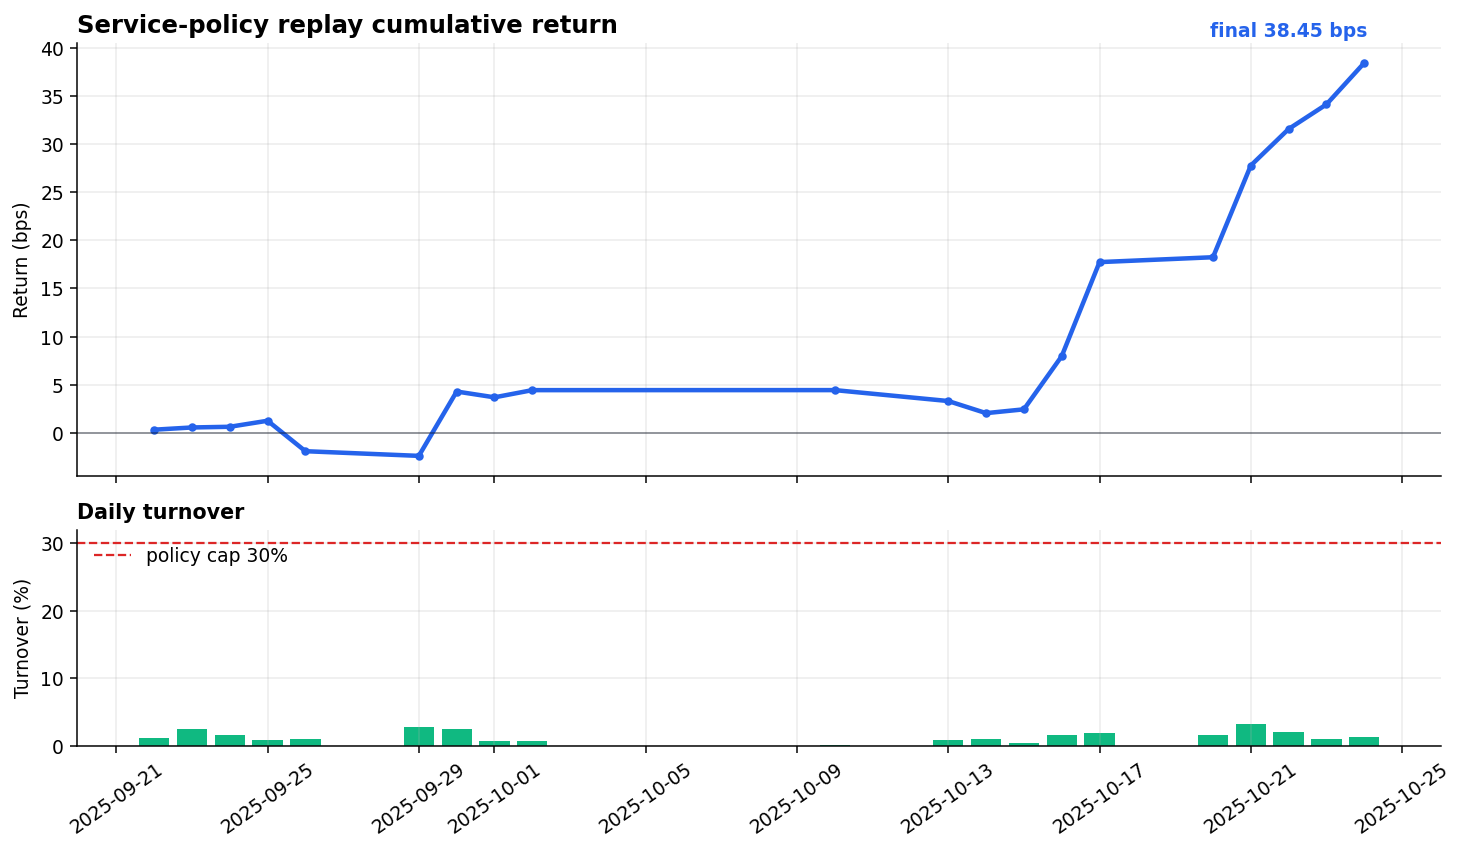

In [10]:
# 누적 수익률은 초기자본 대비 bps로 환산해 표시합니다.
initial = sp_metrics.get('initial_capital', 100000000.0)
daily_equity = sorted(sp.get('daily_equity', {}).items())
daily_turnover = dict(sp.get('daily_turnover', {}))
dates = [datetime.strptime(d, '%Y-%m-%d') for d, _ in daily_equity]
return_bps = [((v / initial) - 1.0) * 10000 for _, v in daily_equity]
turnover_pct = [daily_turnover.get(d, 0.0) * 100 for d, _ in daily_equity]

fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(dates, return_bps, color='#2563eb', linewidth=2.4, marker='o', markersize=3.5)
axes[0].axhline(0, color='#111827', linewidth=0.8, alpha=0.55)
axes[0].set_title('Service-policy replay cumulative return', loc='left', fontsize=13, weight='bold')
axes[0].set_ylabel('Return (bps)')
axes[0].annotate(f"final {return_bps[-1]:.2f} bps", xy=(dates[-1], return_bps[-1]), xytext=(-82, 14), textcoords='offset points', color='#2563eb', weight='bold')
# Turnover 30% cap은 risk_config의 service-policy 제약입니다.
axes[1].bar(dates, turnover_pct, color='#10b981', width=0.8)
axes[1].axhline(30, color='#dc2626', linewidth=1.2, linestyle='--', label='policy cap 30%')
axes[1].set_title('Daily turnover', loc='left', fontsize=11, weight='bold')
axes[1].set_ylabel('Turnover (%)')
axes[1].set_ylim(0, 32)
axes[1].legend(loc='upper left', frameon=False)
for ax in axes:
    ax.tick_params(axis='x', rotation=35)
fig.tight_layout()
plt.show()


## 11. Replay Order Distribution

Replay에서 어떤 종목에 매수/매도 주문이 집중됐는지 확인합니다. 특정 종목에 과도하게 쏠리면 모델보다 포지션 정책 문제가 될 수 있습니다.


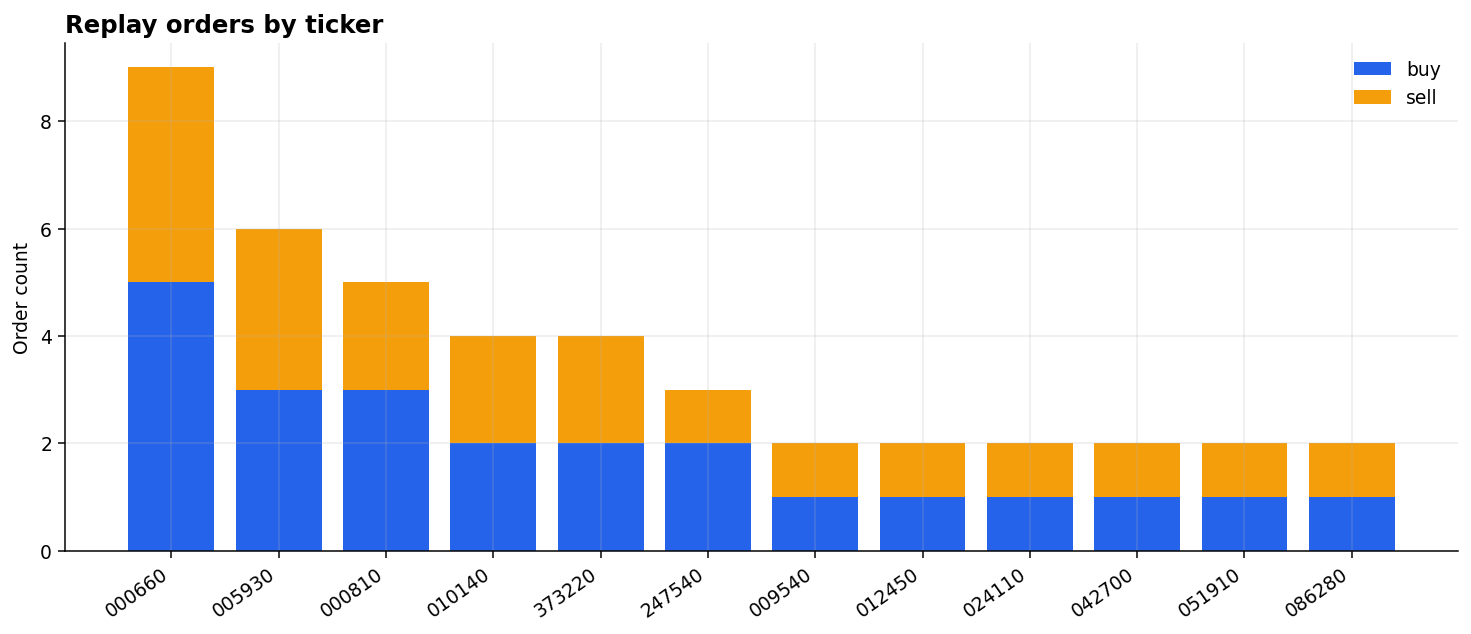

In [11]:
# 주문 분포는 특정 종목 쏠림이 있는지 확인하는 간단한 sanity check입니다.
orders = sp.get('orders', [])
tickers = sorted({o['ticker'] for o in orders})
buy_counts = Counter(o['ticker'] for o in orders if o.get('side') == 'buy')
sell_counts = Counter(o['ticker'] for o in orders if o.get('side') == 'sell')
activity = sorted(tickers, key=lambda t: buy_counts[t] + sell_counts[t], reverse=True)[:12]

fig, ax = plt.subplots(figsize=(11, 4.8))
x = list(range(len(activity)))
buys = [buy_counts[t] for t in activity]
sells = [sell_counts[t] for t in activity]
ax.bar(x, buys, color='#2563eb', label='buy')
ax.bar(x, sells, bottom=buys, color='#f59e0b', label='sell')
ax.set_title('Replay orders by ticker', loc='left', fontsize=13, weight='bold')
ax.set_ylabel('Order count')
ax.set_xticks(x)
ax.set_xticklabels(activity, rotation=35, ha='right')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 12. C12 Backtest Core Metrics

C12 backtest의 핵심 지표를 한눈에 비교합니다. IC/RankIC는 예측 순위 품질, SR/IR은 위험 대비 성과, MDD는 손실 방어력을 봅니다.


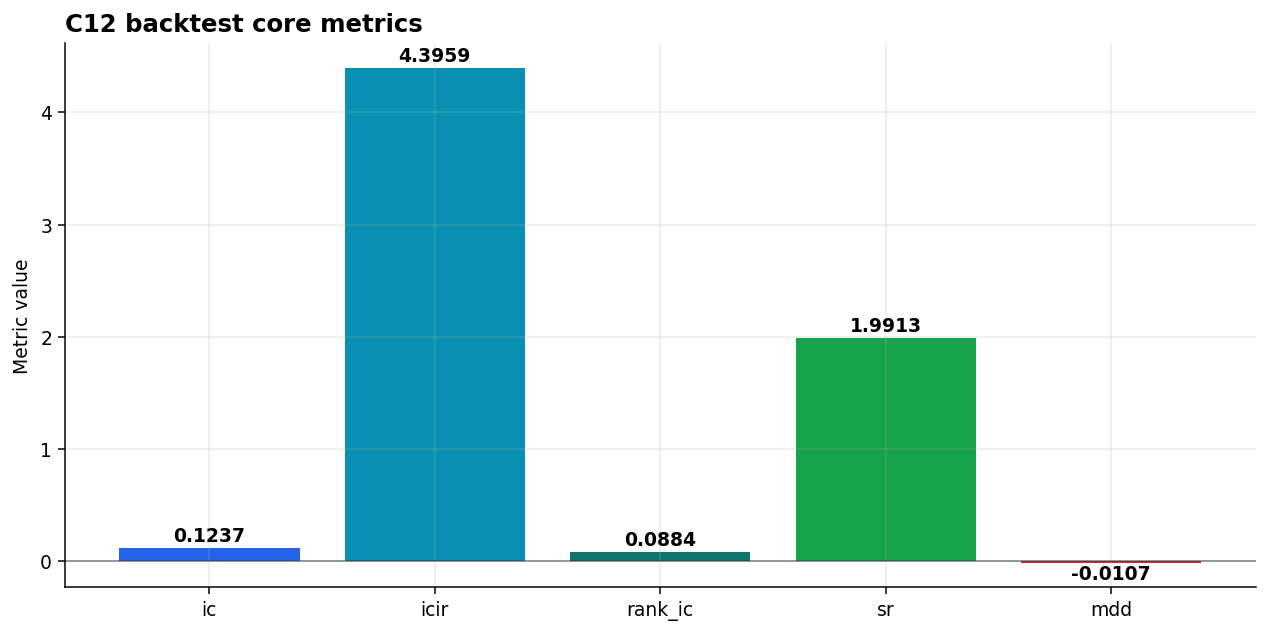

In [12]:
# 서로 스케일이 다른 지표를 한 화면에 놓고 방향성만 빠르게 확인합니다.
metric_names = ['ic', 'icir', 'rank_ic', 'sr', 'mdd']
metric_values = [bt_metrics.get(k, 0.0) for k in metric_names]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.bar(metric_names, metric_values, color=['#2563eb', '#0891b2', '#0f766e', '#16a34a', '#dc2626'])
ax.set_title('C12 backtest core metrics', loc='left', fontsize=13, weight='bold')
ax.axhline(0, color='#111827', linewidth=0.8, alpha=0.55)
for bar, val in zip(bars, metric_values):
    va = 'bottom' if val >= 0 else 'top'
    offset = 0.02 if val >= 0 else -0.02
    ax.text(bar.get_x() + bar.get_width()/2, val + offset, f'{val:.4f}', ha='center', va=va, weight='bold')
ax.set_ylabel('Metric value')
fig.tight_layout()
plt.show()


## 13. C12 Sample Trade Returns

C12 리포트에 포함된 sample trade의 순수익률입니다. 전체 성능을 대표하는 표본은 아니지만, 비용 반영 후 trade 단위 손익 방향을 빠르게 확인하는 용도입니다.


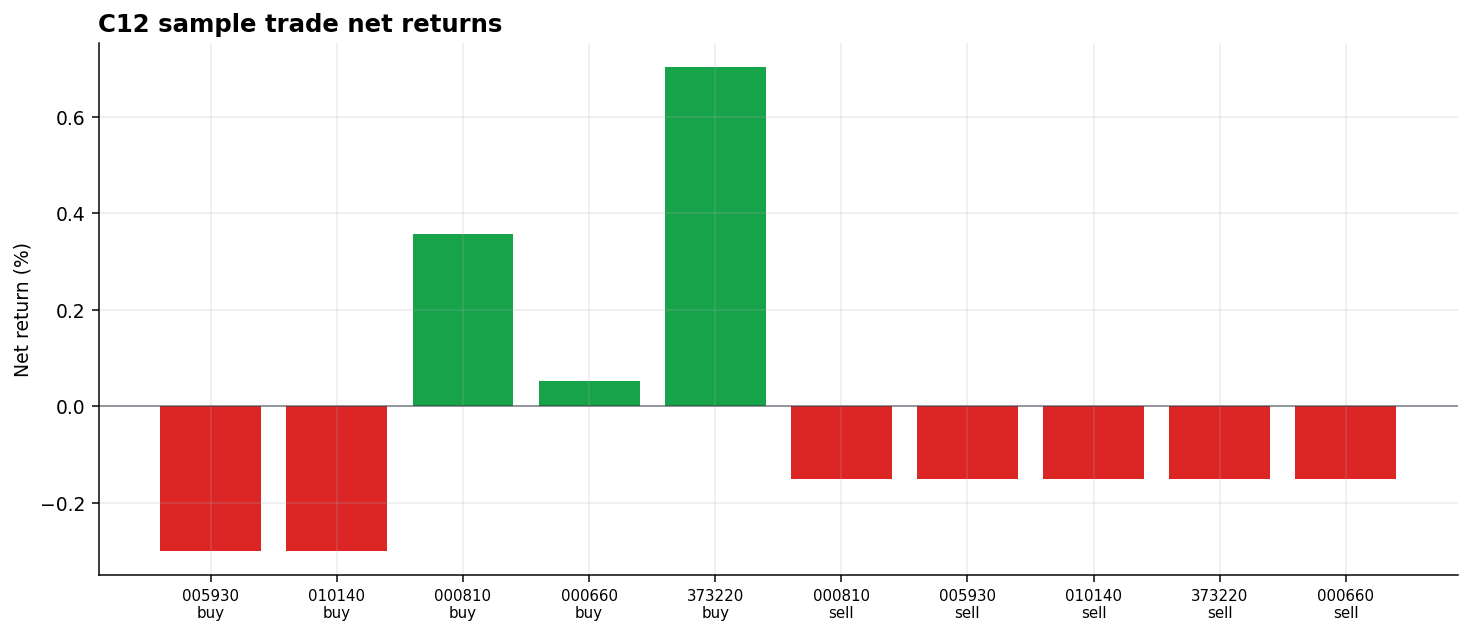

In [13]:
# C12 report의 fold/sample trade rows를 이용해 trade 단위 net return을 확인합니다.
folds = bt.get('folds', [])
if folds:
    labels = [f"{f.get('ticker')}\n{f.get('side')}" for f in folds]
    net = [float(f.get('net_return', 0.0)) * 100 for f in folds]
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.bar(range(len(net)), net, color=['#16a34a' if v >= 0 else '#dc2626' for v in net])
    ax.axhline(0, color='#111827', linewidth=0.8, alpha=0.55)
    ax.set_title('C12 sample trade net returns', loc='left', fontsize=13, weight='bold')
    ax.set_ylabel('Net return (%)')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    fig.tight_layout()
    plt.show()
else:
    display(Markdown('No fold-level trade rows found in the C12 report.'))


## 14. Research Diagnostics

Rolling-window IC와 hyperparameter sweep은 참고용 진단입니다. 이 값만으로 배포를 주장하지 않고, C12와 service-policy replay를 통과했는지 함께 봅니다.


In [14]:
def first_available_rows(report, keys):
    """Return the first non-empty diagnostic row list across possible schema names."""
    for key in keys:
        rows = report.get(key)
        if rows:
            return rows
    return []

# Schema가 조금 바뀌어도 노트북이 깨지지 않도록 후보 key를 순서대로 확인합니다.
rolling_rows = first_available_rows(rolling, ['results', 'experiments'])
if rolling_rows:
    display(Markdown('### Rolling Window IC Experiment'))
    display(pd.DataFrame(rolling_rows).head(10))
else:
    display(Markdown('### Rolling Window IC Experiment'))
    display(pd.DataFrame([{
        'status': rolling.get('status'),
        'report_path': rolling.get('report_path_relative', display_path(REPORTS['rolling_window'])),
    }]))

sweep_rows = first_available_rows(sweep, ['results', 'experiments', 'candidates'])
if sweep_rows:
    display(Markdown('### Hyperparameter Sweep'))
    display(pd.DataFrame(sweep_rows).head(10))
else:
    display(Markdown('### Hyperparameter Sweep'))
    display(pd.DataFrame([{
        'status': sweep.get('status'),
        'report_path': sweep.get('report_path_relative', display_path(REPORTS['hyperparam_sweep'])),
    }]))


### Rolling Window IC Experiment

,window_mode,window_days,group,feature_count,feature_cols,fold_count,mean_ic,mean_rank_ic,mean_daily_pnl,fold_metrics
0,rolling,120,OHLCV,4,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.001326,-0.005186,-0.002496,"[{'ic': -0.014031324888638638, 'rank_ic': -0.0..."
1,rolling,120,OHLCV+Exog,13,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.033839,0.029580,-0.002251,"[{'ic': -0.023360643353803234, 'rank_ic': -0.0..."
2,rolling,120,OHLCV+News_DS,5,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,-0.009112,-0.013758,-0.002834,"[{'ic': -0.0020124595807416473, 'rank_ic': -0...."
3,rolling,120,OHLCV+Exog+News_DS,14,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.014431,0.012767,-0.002510,"[{'ic': -0.025732479037236848, 'rank_ic': -0.0..."
4,rolling,150,OHLCV,4,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.013933,0.005150,-0.002064,"[{'ic': 0.011231432707889587, 'rank_ic': -0.00..."
5,rolling,150,OHLCV+Exog,13,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.018442,0.015006,-0.001716,"[{'ic': -0.0004088858665832146, 'rank_ic': -0...."
6,rolling,150,OHLCV+News_DS,5,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,-0.018328,-0.022117,-0.002669,"[{'ic': -0.05878503110528463, 'rank_ic': -0.05..."
7,rolling,150,OHLCV+Exog+News_DS,14,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.019684,0.015787,-0.001852,"[{'ic': -0.03917594134924634, 'rank_ic': -0.05..."
8,rolling,180,OHLCV,4,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.000690,-0.005825,-0.002966,"[{'ic': -0.04979367240348636, 'rank_ic': -0.04..."
9,rolling,180,OHLCV+Exog,13,"[feat_1m_close_robust_z, feat_5m_ret, feat_30m...",5,0.041356,0.034287,-0.002270,"[{'ic': 0.0636355233784233, 'rank_ic': 0.05593..."


### Hyperparameter Sweep

,status,candidate_name,version,window_days,group,train_start,train_end,target_col,feature_count,feature_policy,...,n_folds,n_train_rows,n_cv_last_train_rows,n_val_rows,final_num_boost_round,cv_best_iterations,lgbm_params,training_control,model_path,registry_dir
0,PASS,baseline_lr005_l31_c20,hp-baseline-lr005-l31-c20-w253-ohlcv-exog-news-ds,253,OHLCV+Exog+News_DS,20250509,20260521,label_195m_net_ret,14,"{'include_dual_source': True, 'include_exogeno...",...,8,1405090,330078,108335,8,"[61, 36, 2, 3, 1, 20, 6, 10]","{'objective': 'lambdarank', 'metric': 'ndcg', ...","{'n_estimators': 500, 'early_stopping_rounds':...",,
1,PASS,regularized_lr003_l31_c50,hp-regularized-lr003-l31-c50-w253-ohlcv-exog-n...,253,OHLCV+Exog+News_DS,20250509,20260521,label_195m_net_ret,14,"{'include_dual_source': True, 'include_exogeno...",...,8,1405090,330078,108335,7,"[61, 8, 8, 1, 5, 1, 13, 6]","{'objective': 'lambdarank', 'metric': 'ndcg', ...","{'n_estimators': 700, 'early_stopping_rounds':...",,
2,PASS,small_leaf_lr005_l15_c50,hp-small-leaf-lr005-l15-c50-w253-ohlcv-exog-ne...,253,OHLCV+Exog+News_DS,20250509,20260521,label_195m_net_ret,14,"{'include_dual_source': True, 'include_exogeno...",...,8,1405090,330078,108335,9,"[22, 7, 11, 99, 1, 6, 5, 15]","{'objective': 'lambdarank', 'metric': 'ndcg', ...","{'n_estimators': 500, 'early_stopping_rounds':...",,


## 15. Validation Verdict

팀 공유용 최종 요약입니다. 여기서 `deployable=True`는 dry-run 기준 모델 후보가 배포 가능하다는 뜻이며, 실계좌/모의투자 자동매매 시작 가능을 의미하지는 않습니다.


In [15]:
# 마지막 셀은 발표/공유 시 그대로 캡처할 수 있는 최종 판정 테이블입니다.
verdict_df = pd.DataFrame([
    {'item': 'service_policy_replay_status', 'value': sp.get('status')},
    {'item': 'service_policy_total_return_bps', 'value': round(sp_metrics.get('total_return_bps', 0.0), 4)},
    {'item': 'service_policy_sharpe', 'value': round(sp_metrics.get('sr', 0.0), 4)},
    {'item': 'c12_backtest_verdict', 'value': bt.get('verdict')},
    {'item': 'c12_ic', 'value': round(bt_metrics.get('ic', 0.0), 4)},
    {'item': 'c12_rank_ic', 'value': round(bt_metrics.get('rank_ic', 0.0), 4)},
    {'item': 'c12_sharpe', 'value': round(bt_metrics.get('sr', 0.0), 4)},
    {'item': 'deploy_dry_run_status', 'value': deploy.get('status')},
    {'item': 'deployable', 'value': deploy.get('deployable')},
    {'item': 'registry_mutated', 'value': deploy.get('registry_mutated')},
    {'item': 'minute_bar_leakage_verdict', 'value': bt_leak.get('verdict')},
    {'item': 'regression_risk_flagged', 'value': bt_risk.get('flagged')},
])

display(verdict_df)


,item,value
0,service_policy_replay_status,PASS
1,service_policy_total_return_bps,38.4466
2,service_policy_sharpe,8.5394
3,c12_backtest_verdict,pass
4,c12_ic,0.1237
5,c12_rank_ic,0.0884
6,c12_sharpe,1.9913
7,deploy_dry_run_status,PASS
8,deployable,True
9,registry_mutated,False
